## Description
Source: https://physionet.org/content/ptb-xl/1.0.3/

# Abstract
Electrocardiography (ECG) is a key diagnostic tool to assess the cardiac condition of a patient. Automatic ECG interpretation algorithms as diagnosis support systems promise large reliefs for the medical personnel - only on the basis of the number of ECGs that are routinely taken. However, the development of such algorithms requires large training datasets and clear benchmark procedures. In our opinion, both aspects are not covered satisfactorily by existing freely accessible ECG datasets.

The PTB-XL ECG dataset is a large dataset of 21837 clinical 12-lead ECGs from 18885 patients of 10 second length. The raw waveform data was annotated by up to two cardiologists, who assigned potentially multiple ECG statements to each record. The in total 71 different ECG statements conform to the SCP-ECG standard and cover diagnostic, form, and rhythm statements. To ensure comparability of machine learning algorithms trained on the dataset, we provide recommended splits into training and test sets. In combination with the extensive annotation, this turns the dataset into a rich resource for the training and the evaluation of automatic ECG interpretation algorithms. The dataset is complemented by extensive metadata on demographics, infarction characteristics, likelihoods for diagnostic ECG statements as well as annotated signal properties.

# Background
The waveform data underlying the PTB-XL ECG dataset was collected with devices from Schiller AG over the course of nearly seven years between October 1989 and June 1996. With the acquisition of the original database from Schiller AG, the full usage rights were transferred to the PTB. The records were curated and converted into a structured database within a long-term project at the Physikalisch-Technische Bundesanstalt (PTB). The database was used in a number of publications, but the access remained restricted until now. The Institutional Ethics Committee approved the publication of the anonymous data in an open-access database (PTB-2020-1). During the public release process in 2019, the existing database was streamlined with particular regard to usability and accessibility for the machine learning community. Waveform and metadata were converted to open data formats that can easily processed by standard software.

# Methods
## Data Acquisition
1. Raw signal data was recorded and stored in a proprietary compressed format. For all signals, we provide the standard set of 12 leads (I, II, III, AVL, AVR, AVF, V1, …, V6) with reference electrodes on the right arm.
2. The corresponding general metadata (such as age, sex, weight and height) was collected in a database.
3. Each record was annotated with a report string (generated by cardiologist or automatic interpretation by ECG-device) which was converted into a standardized set of SCP-ECG statements (scp_codes). For most records also the heart’s axis (`heart_axis`) and infarction stadium (`infarction_stadium1` and `infarction_stadium2`, if present) were extracted.
4. A large fraction of the records was validated by a second cardiologist.
5. All records were validated by a technical expert focusing mainly on signal characteristics.

## Data Preprocessing
ECGs and patients are identified by unique identifiers (`ecg_id` and `patient_id`). Personal information in the metadata, such as names of validating cardiologists, nurses and recording site (hospital etc.) of the recording was pseudonymized. The date of birth only as age at the time of the ECG recording, where ages of more than 89 years appear in the range of 300 years in compliance with HIPAA standards. Furthermore, all ECG recording dates were shifted by a random offset for each patient. The ECG statements used for annotating the records follow the SCP-ECG standard.

## Data Description
In general, the dataset is organized as follows:

`ptbxl
├── ptbxl_database.csv
├── scp_statements.csv
├── records100
├── 00000
│   │   ├── 00001_lr.dat
│   │   ├── 00001_lr.hea
│   │   ├── ...
│   │   ├── 00999_lr.dat
│   │   └── 00999_lr.hea
│   ├── ...
│   └── 21000
│        ├── 21001_lr.dat
│        ├── 21001_lr.hea
│        ├── ...
│        ├── 21837_lr.dat
│        └── 21837_lr.hea
└── records500
   ├── 00000
   │     ├── 00001_hr.dat
   │     ├── 00001_hr.hea
   │     ├── ...
   │     ├── 00999_hr.dat
   │     └── 00999_hr.hea
   ├── ...
   └── 21000
          ├── 21001_hr.dat
          ├── 21001_hr.hea
          ├── ...
          ├── 21837_hr.dat
          └── 21837_hr.hea`
          
The dataset comprises 21837 clinical 12-lead ECG records of 10 seconds length from 18885 patients, where 52% are male and 48% are female with ages covering the whole range from 0 to 95 years (median 62 and interquantile range of 22). The value of the dataset results from the comprehensive collection of many different co-occurring pathologies, but also from a large proportion of healthy control samples. The distribution of diagnosis is as follows, where we restrict for simplicity to diagnostic statements aggregated into superclasses (note: sum of statements exceeds the number of records because of potentially multiple labels per record):

`Records | Superclass | Description
9528 | NORM | Normal ECG
5486 | MI | Myocardial Infarction
5250 | STTC | ST/T Change
4907 | CD | Conduction Disturbance
2655 | HYP | Hypertrophy`

The waveform files are stored in WaveForm DataBase (WFDB) format with 16 bit precision at a resolution of 1μV/LSB and a sampling frequency of 500Hz (records500/). For the user’s convenience we also release a downsampled versions of the waveform data at a sampling frequency of 100Hz (records100/).

All relevant metadata is stored in ptbxldatabase.csv with one row per record identified by ecgid. It contains 28 columns that can be categorized into:

1. Identifiers: Each record is identified by a unique `ecg_id`. The corresponding patient is encoded via patient_id. The paths to the original record (500 Hz) and a downsampled version of the record (100 Hz) are stored in `filename_hr` and `filename_lr`.
2. General Metadata: demographic and recording metadata such as age, sex, height, weight, nurse, site, device and recording_date
3. ECG statements: core components are `scp_codes` (SCP-ECG statements as a dictionary with entries of the form statement: likelihood, where likelihood is set to 0 if unknown) and report (report string). Additional fields are heart_axis, infarction_stadium1, infarction_stadium2, validated_by, second_opinion, initial_autogenerated_report and validated_by_human.
4. Signal Metadata: signal quality such as noise (static_noise and burst_noise), baseline drifts (baseline_drift) and other artifacts such as electrodes_problems. We also provide extra_beats for counting extra systoles and pacemaker for signal patterns indicating an active pacemaker.
5. Cross-validation Folds: recommended 10-fold train-test splits (strat_fold) obtained via stratified sampling while respecting patient assignments, i.e. all records of a particular patient were assigned to the same fold. Records in fold 9 and 10 underwent at least one human evaluation and are therefore of a particularly high label quality. We therefore propose to use folds 1-8 as training set, fold 9 as validation set and fold 10 as test set.


<img src= "https://i.ibb.co/VgtRfzH/META.png" alt ="META" style='width: 850px;'>


All information related to the used annotation scheme is stored in a dedicated scp_statements.csv that was enriched with mappings to other annotation standards such as AHA, aECGREFID, CDISC and DICOM. We provide additional side-information such as the category each statement can be assigned to (diagnostic, form and/or rhythm). For diagnostic statements, we also provide a proposed hierarchical organization into diagnostic_class and diagnostic_subclass.

In [1]:
import tensorflow as tf

print("--> Checking for physical Tensorflow devices")
for device in tf.config.list_physical_devices():
    print(": {}".format(device.name))
    
device_name = tf.test.gpu_device_name()

if "GPU" not in device_name:
    print("GPU device not found")
    
print('Found GPU at: {}'.format(device_name))

print("GPU", "available" if tf.config.list_physical_devices("GPU") else "not available :(")

--> Checking for physical Tensorflow devices
: /physical_device:CPU:0
: /physical_device:GPU:0
: /physical_device:GPU:1
Found GPU at: /device:GPU:0
GPU available


In [2]:
!pip install ecg-plot

In [3]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install wfdb

Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install keras-tuner tensorflow-addons

Note: you may need to restart the kernel to use updated packages.


# EDA

In [6]:
import pandas as pd
import numpy as np
import os
import wfdb
import ast
import ecg_plot
import time
from tqdm import tqdm
import warnings; warnings.filterwarnings('ignore')
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling1D, Activation, BatchNormalization, Conv1D, MaxPooling1D, Add, Activation, Dropout
from tensorflow.keras.optimizers import Adam, SGD, RMSprop, Adagrad
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, hamming_loss, confusion_matrix
from tensorflow.keras import regularizers
import gc
import subprocess
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import scipy.stats as stats
from scipy.stats import chi2_contingency
from scipy import __version__ as scipy_version  # Import scipy version directly
from tensorflow.keras.callbacks import LearningRateScheduler, EarlyStopping, Callback, ReduceLROnPlateau
from tensorflow.keras import backend as K
import tensorflow as tf
import random  # Import the random module
from sklearn.metrics import roc_auc_score, roc_curve, auc

# Setting random seeds for reproducibility
SEED = 3

# Function to set all seeds
def set_all_seeds(seed=SEED):
    # Environment variable
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    # Python's built-in random module
    random.seed(seed)
    
    # NumPy
    np.random.seed(seed)
    
    # TensorFlow
    tf.random.set_seed(seed)
    
    # PyTorch
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Set seeds initially
set_all_seeds()

In [7]:
os.environ['PYTHONHASHSEED'] = str(SEED)

In [8]:
# Function to generate and print random numbers from each library
def generate_random_numbers():
    # Set seeds before generating random numbers
    set_all_seeds()
    
    print("Random number from Python's random module:", random.randint(0, 100))
    print("Random number from NumPy:", np.random.randint(0, 100))
    print("Random number from TensorFlow:", tf.random.uniform((1,), minval=0, maxval=100, dtype=tf.int32).numpy()[0])
    print("Random number from PyTorch:", torch.randint(0, 100, (1,)).item())

# Initial seed setting and random number generation
print("Initial random number generation:")
generate_random_numbers()

# Re-run to check for consistency
print("\nRe-running the random number generation to check for consistency:")
generate_random_numbers()

Initial random number generation:
Random number from Python's random module: 30
Random number from NumPy: 24
Random number from TensorFlow: 24
Random number from PyTorch: 86

Re-running the random number generation to check for consistency:
Random number from Python's random module: 30
Random number from NumPy: 24
Random number from TensorFlow: 24
Random number from PyTorch: 86


## Load Raw Data

In [9]:
DATA_DIR = "/kaggle/input/ptb-xl-1-0-3"   # <- change this to your actual folder
import os
print("Exists?", os.path.exists(DATA_DIR))
print("Files:", sorted(os.listdir(DATA_DIR))[:20])
import pandas as pd
meta = pd.read_csv(os.path.join(DATA_DIR, "/kaggle/input/ptb-xl-1-0-3/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/ptbxl_database.csv"))
meta.head(5)

Exists? True
Files: ['ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3']


,ecg_id,patient_id,age,sex,height,weight,nurse,site,device,recording_date,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
0,1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
1,2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
2,3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,...,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr
3,4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,...,True,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr
4,5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,...,True,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr


In [10]:
!ls /kaggle/input/ptb-xl-1-0-3/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/records100/00000


00001_lr.dat  00205_lr.hea  00403_lr.dat  00605_lr.hea	00803_lr.dat
00001_lr.hea  00206_lr.dat  00403_lr.hea  00606_lr.dat	00803_lr.hea
00002_lr.dat  00206_lr.hea  00404_lr.dat  00606_lr.hea	00804_lr.dat
00002_lr.hea  00207_lr.dat  00404_lr.hea  00607_lr.dat	00804_lr.hea
00003_lr.dat  00207_lr.hea  00405_lr.dat  00607_lr.hea	00805_lr.dat
00003_lr.hea  00208_lr.dat  00405_lr.hea  00608_lr.dat	00805_lr.hea
00004_lr.dat  00208_lr.hea  00406_lr.dat  00608_lr.hea	00806_lr.dat
00004_lr.hea  00209_lr.dat  00406_lr.hea  00609_lr.dat	00806_lr.hea
00005_lr.dat  00209_lr.hea  00407_lr.dat  00609_lr.hea	00807_lr.dat
00005_lr.hea  00210_lr.dat  00407_lr.hea  00610_lr.dat	00807_lr.hea
00006_lr.dat  00210_lr.hea  00408_lr.dat  00610_lr.hea	00808_lr.dat
00006_lr.hea  00211_lr.dat  00408_lr.hea  00611_lr.dat	00808_lr.hea
00007_lr.dat  00211_lr.hea  00409_lr.dat  00611_lr.hea	00809_lr.dat
00007_lr.hea  00212_lr.dat  00409_lr.hea  00612_lr.dat	00809_lr.hea
00008_lr.dat  00212_lr.hea  00410_lr.dat  00612_

In [11]:
DATA_DIR = "/kaggle/input/ptb-xl-1-0-3/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3"

import pandas as pd, os, wfdb

meta = pd.read_csv(os.path.join(DATA_DIR, "ptbxl_database.csv"))

record_path = os.path.join(DATA_DIR, meta.iloc[0]['filename_lr'])
print("Loading:", record_path)

rec = wfdb.rdrecord(record_path)
sig = rec.p_signal
print("Signal shape:", sig.shape)


Loading: /kaggle/input/ptb-xl-1-0-3/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/records100/00000/00001_lr
Signal shape: (1000, 12)


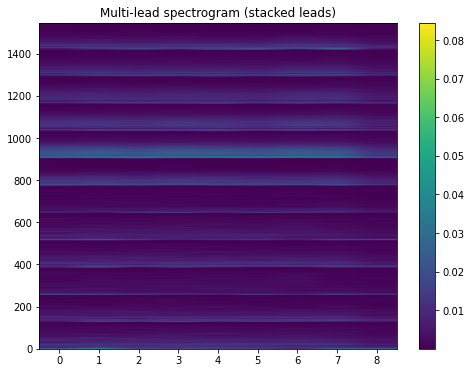

In [12]:
from scipy.signal import stft
def signal_to_spectrogram(sig_channel, fs=rec.fs, nperseg=256, noverlap=128):
    f, tt, Zxx = stft(sig_channel, fs=fs, nperseg=nperseg, noverlap=noverlap)
    S = np.abs(Zxx)
    S = np.log1p(S)      # log-scale
    return S, f, tt

# make a multi-lead spectrogram image by concatenating per-lead specs vertically
specs = []
for i in range(sig.shape[1]):  # for each lead
    S, f, tt = signal_to_spectrogram(sig[:,i], fs=rec.fs)
    specs.append(S)
# pad to same height and horizontally stack (or vertical stack)
img = np.vstack(specs)  # large 2D array
plt.figure(figsize=(8,6))
plt.imshow(img, aspect='auto', origin='lower')
plt.title("Multi-lead spectrogram (stacked leads)")
plt.colorbar()
plt.show()

In [13]:
import os, pandas as pd
DATA_DIR = "/kaggle/input/ptb-xl-1-0-3/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3"
meta = pd.read_csv(os.path.join(DATA_DIR, "ptbxl_database.csv"))
meta.head()

,ecg_id,patient_id,age,sex,height,weight,nurse,site,device,recording_date,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
0,1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
1,2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
2,3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,...,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr
3,4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,...,True,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr
4,5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,...,True,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr


In [14]:

meta.columns

Index(['ecg_id', 'patient_id', 'age', 'sex', 'height', 'weight', 'nurse',
       'site', 'device', 'recording_date', 'report', 'scp_codes', 'heart_axis',
       'infarction_stadium1', 'infarction_stadium2', 'validated_by',
       'second_opinion', 'initial_autogenerated_report', 'validated_by_human',
       'baseline_drift', 'static_noise', 'burst_noise', 'electrodes_problems',
       'extra_beats', 'pacemaker', 'strat_fold', 'filename_lr', 'filename_hr'],
      dtype='object')

0.0    8940
1.0    6294
2.0    5075
3.0     576
4.0     100
5.0      58
6.0      46
7.0      43
8.0      43
9.0      38
Name: site, dtype: int64

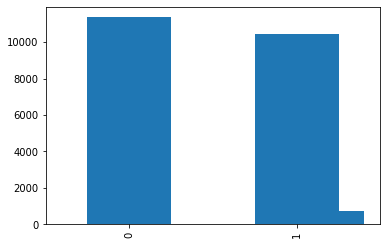

In [15]:
import ast

meta['num_labels'] = meta['scp_codes'].apply(lambda x: len(ast.literal_eval(x)))
meta['num_labels'].hist(bins=20)

meta['age'].hist(bins=20)
meta['sex'].value_counts().plot(kind='bar')
meta['validated_by_human'].value_counts()
meta['site'].value_counts().head(10)

NORM     9514
IMI      2676
ASMI     2357
LVH      2354
NDT      1825
LAFB     1623
ISC_     1272
IRBBB    1118
LMI      1018
1AVB      793
dtype: int64

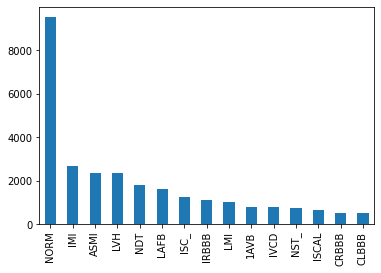

In [16]:
scp_df = pd.read_csv(f"{DATA_DIR}/scp_statements.csv", index_col=0)
scp_df = scp_df[scp_df.diagnostic_class.notnull()]
scp_freq = {code: sum(code in scp for scp in meta['scp_codes']) for code in scp_df.index}
scp_freq = pd.Series(scp_freq).sort_values(ascending=False)
scp_freq.head(15).plot(kind='bar')
scp_freq.head(10)

In [17]:
# Run this once
!pip install wfdb transformers sentence-transformers scikit-learn torch torchvision tqdm

In [18]:
import os, ast, random, math, json, time
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import wfdb
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import roc_auc_score, f1_score, classification_report

# Config
DATA_DIR = "/kaggle/input/ptb-xl-1-0-3/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3"
CSV_META = os.path.join(DATA_DIR, "ptbxl_database.csv")
SCP_CSV = os.path.join(DATA_DIR, "scp_statements.csv")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

In [19]:
# Step 1: Load metadata and choose labels (fixed)
meta = pd.read_csv(CSV_META)
print("Total rows:", len(meta))

# PTB-XL v1.0.3 uses 'scp_codes', not 'diagnostic_superclass'
all_codes = {}
for s in meta['scp_codes'].dropna():
    d = ast.literal_eval(s)  # convert string dict to actual dict
    for k in d.keys():
        all_codes[k] = all_codes.get(k,0)+1

# Choose top-K frequent SCP codes
TOPK = 5
top_codes = sorted(all_codes.items(), key=lambda x: -x[1])[:TOPK]
label_map = {k:i for i,(k,_) in enumerate(top_codes)}
print("Label map (top SCP codes):", label_map)

# Create per-record label: if record contains a top code, assign it
def get_label_from_scp(s):
    if pd.isna(s): return None
    d = ast.literal_eval(s)
    for k in label_map:
        if k in d: return k
    return None

meta['chosen_label'] = meta['scp_codes'].apply(get_label_from_scp)
meta = meta[meta['chosen_label'].notnull()].reset_index(drop=True)
print("Rows after label filtering:", len(meta))

# Patient-level train/val/test split
unique_pat = meta['patient_id'].unique()
np.random.shuffle(unique_pat)
n = len(unique_pat)
train_p = set(unique_pat[:int(0.7*n)])
val_p   = set(unique_pat[int(0.7*n):int(0.85*n)])
test_p  = set(unique_pat[int(0.85*n):])

meta['split'] = meta['patient_id'].apply(
    lambda x: 'train' if x in train_p else ('val' if x in val_p else 'test')
)
print(meta['split'].value_counts())

Total rows: 21799
Label map (top SCP codes): {'SR': 0, 'NORM': 1, 'ABQRS': 2, 'IMI': 3, 'ASMI': 4}
Rows after label filtering: 19533
train    13617
val       2959
test      2957
Name: split, dtype: int64


In [20]:
import os, ast, random, math
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
from torch.utils.data import Dataset, DataLoader

# HuggingFace
from transformers import AutoTokenizer

# Config
DATA_DIR = "/kaggle/input/ptb-xl-1-0-3/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3"
CSV_META = os.path.join(DATA_DIR, "ptbxl_database.csv")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

TOPK = 5  # number of labels to focus on
SEQ_LEN = 5000  # ECG length to trim/pad


In [21]:
# Load CSV
meta = pd.read_csv(CSV_META)
print("Meta columns:", meta.columns)

# Check if 'diagnostic_superclass' exists
if 'diagnostic_superclass' in meta.columns:
    # Use diagnostic_superclass
    top_labels = meta['diagnostic_superclass'].value_counts().nlargest(TOPK).index.tolist()
    label_map = {lab: i for i, lab in enumerate(top_labels)}
    meta = meta[meta['diagnostic_superclass'].isin(top_labels)].reset_index(drop=True)
    label_col = 'diagnostic_superclass'
else:
    # Fallback: parse scp_codes
    all_codes = {}
    for s in meta['scp_codes'].dropna():
        d = ast.literal_eval(s)
        for k in d.keys():
            all_codes[k] = all_codes.get(k, 0) + 1
    top_codes = sorted(all_codes.items(), key=lambda x: -x[1])[:TOPK]
    label_map = {k:i for i, (k, _) in enumerate(top_codes)}
    print("Label map (from SCP codes):", label_map)
    
    # Create a column 'chosen_label' for top-K SCP codes
    def get_label_from_scp(s):
        if pd.isna(s): return None
        d = ast.literal_eval(s)
        for k in label_map:
            if k in d: return k
        return None
    meta['chosen_label'] = meta['scp_codes'].apply(get_label_from_scp)
    meta = meta[meta['chosen_label'].notnull()].reset_index(drop=True)
    label_col = 'chosen_label'

print("Rows after filtering:", len(meta))


Meta columns: Index(['ecg_id', 'patient_id', 'age', 'sex', 'height', 'weight', 'nurse',
       'site', 'device', 'recording_date', 'report', 'scp_codes', 'heart_axis',
       'infarction_stadium1', 'infarction_stadium2', 'validated_by',
       'second_opinion', 'initial_autogenerated_report', 'validated_by_human',
       'baseline_drift', 'static_noise', 'burst_noise', 'electrodes_problems',
       'extra_beats', 'pacemaker', 'strat_fold', 'filename_lr', 'filename_hr'],
      dtype='object')
Label map (from SCP codes): {'SR': 0, 'NORM': 1, 'ABQRS': 2, 'IMI': 3, 'ASMI': 4}
Rows after filtering: 19533


In [22]:
unique_pat = meta['patient_id'].unique()
np.random.shuffle(unique_pat)
n = len(unique_pat)
train_p = set(unique_pat[:int(0.7*n)])
val_p   = set(unique_pat[int(0.7*n):int(0.85*n)])
test_p  = set(unique_pat[int(0.85*n):])

meta['split'] = meta['patient_id'].apply(lambda x: 'train' if x in train_p else ('val' if x in val_p else 'test'))
print(meta['split'].value_counts())


train    13617
val       2959
test      2957
Name: split, dtype: int64


In [23]:
class PTBXLDataset(Dataset):
    def __init__(self, meta_df, data_dir, label_map, split='train', seq_len=SEQ_LEN, use_hr=False):
        self.df = meta_df[meta_df['split']==split].reset_index(drop=True)
        self.data_dir = data_dir
        self.seq_len = seq_len
        self.use_hr = use_hr
        self.label_map = label_map

    def __len__(self):
        return len(self.df)

    def _load_signal(self, row):
        fname = row['filename_hr'] if self.use_hr else row['filename_lr']
        path = os.path.join(self.data_dir, fname)
        rec = wfdb.rdrecord(path)
        sig = rec.p_signal.T.astype(np.float32)  # shape [12, samples]
        ns = sig.shape[1]
        if ns >= self.seq_len:
            sig = sig[:, :self.seq_len]
        else:
            pad = np.zeros((sig.shape[0], self.seq_len - ns), dtype=np.float32)
            sig = np.concatenate([sig, pad], axis=1)
        # per-lead normalization
        mean = sig.mean(axis=1, keepdims=True)
        std = sig.std(axis=1, keepdims=True) + 1e-6
        sig = (sig - mean)/std
        return sig

    def _get_label_vec(self, row):
        vec = np.zeros(len(self.label_map), dtype=np.float32)
        lab = row[label_col]
        if lab in self.label_map:
            vec[self.label_map[lab]] = 1.0
        return vec

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        sig = self._load_signal(row)
        text = row.get('report', "") or row.get('initial_autogenerated_report', "") or ""
        label_vec = self._get_label_vec(row)
        return torch.tensor(sig, dtype=torch.float32), text, torch.tensor(label_vec, dtype=torch.float32), row['ecg_id']


In [24]:
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def collate_fn(batch):
    sigs = torch.stack([b[0] for b in batch])
    labels = torch.stack([b[2] for b in batch])
    texts = [b[1] for b in batch]
    enc = tokenizer(texts, padding=True, truncation=True, max_length=128, return_tensors='pt')
    return sigs, enc, labels

In [25]:
train_meta = meta[meta['split']=='train'].sample(min(100, meta[meta['split']=='train'].shape[0]), random_state=SEED)
val_meta = meta[meta['split']=='val'].sample(min(20, meta[meta['split']=='val'].shape[0]), random_state=SEED)

train_ds = PTBXLDataset(train_meta, DATA_DIR, label_map, split='train')
val_ds   = PTBXLDataset(val_meta, DATA_DIR, label_map, split='val')

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_ds, batch_size=4, shuffle=False, collate_fn=collate_fn)

# Test batch
for ecg, text_enc, labels in train_loader:
    print("ECG batch:", ecg.shape)
    print("Text batch input_ids:", text_enc['input_ids'].shape)
    print("Label batch:", labels.shape)
    break


Ignored unknown kwarg option direction
ECG batch: torch.Size([4, 12, 5000])
Text batch input_ids: torch.Size([4, 48])
Label batch: torch.Size([4, 5])


In [26]:
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoModel

# --------- ECG Encoder ---------
class ECGConvEncoder(nn.Module):
    def __init__(self, in_ch=12, d_model=128, downsample=16):
        super().__init__()
        self.conv1 = nn.Conv1d(in_ch, 64, kernel_size=7, padding=3)
        self.bn1 = nn.BatchNorm1d(64)
        self.conv2 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(128)
        self.pool = nn.AvgPool1d(downsample)
        self.proj = nn.Conv1d(128, d_model, kernel_size=1)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)
        x = self.proj(x)
        x = x.permute(0, 2, 1)  # [B, T, d_model]
        return x


In [27]:
# --------- Cross-Attention Fusion ---------
class CrossAttentionFusion(nn.Module):
    def __init__(self, d_model=128, n_heads=4):
        super().__init__()
        self.attn = nn.MultiheadAttention(d_model, n_heads, batch_first=True)
        self.norm = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(nn.Linear(d_model, d_model), nn.ReLU(), nn.Linear(d_model, d_model))

    def forward(self, ecg_tokens, text_tokens, text_mask=None):
        key_padding_mask = (text_mask==0) if text_mask is not None else None
        attn_out, _ = self.attn(query=ecg_tokens, key=text_tokens, value=text_tokens, key_padding_mask=key_padding_mask)
        out = self.norm(ecg_tokens + attn_out)
        out = out + self.ff(out)
        return out


In [28]:
# --------- Full Multimodal Model ---------
class MultimodalECGModel(nn.Module):
    def __init__(self, n_classes, d_model=128, bert_name="distilbert-base-uncased"):
        super().__init__()
        self.ecg_enc = ECGConvEncoder(d_model=d_model)
        self.tokenizer = AutoTokenizer.from_pretrained(bert_name)
        self.bert = AutoModel.from_pretrained(bert_name)
        self.text_proj = nn.Linear(self.bert.config.hidden_size, d_model)
        self.fusion = CrossAttentionFusion(d_model=d_model)
        self.classifier = nn.Sequential(
            nn.Linear(d_model, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, n_classes)
        )

    def forward(self, ecg, text_enc):
        # ECG -> token embeddings
        ecg_tokens = self.ecg_enc(ecg)
        # Text -> BERT embeddings
        input_ids = text_enc['input_ids'].to(ecg.device)
        attention_mask = text_enc['attention_mask'].to(ecg.device)
        text_out = self.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        text_tokens = self.text_proj(text_out)
        # Fusion
        fused = self.fusion(ecg_tokens, text_tokens, text_mask=attention_mask)
        # Pool over time
        pooled = fused.mean(dim=1)
        logits = self.classifier(pooled)
        return logits


In [35]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ECGOnlyModel(nn.Module):
    def __init__(self, n_classes=5):
        super(ECGOnlyModel, self).__init__()
        
        self.conv1 = nn.Conv1d(12, 32, kernel_size=7, stride=2, padding=3)
        self.bn1 = nn.BatchNorm1d(32)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, stride=2, padding=2)
        self.bn2 = nn.BatchNorm1d(64)
        self.conv3 = nn.Conv1d(64, 128, kernel_size=3, stride=2, padding=1)
        self.bn3 = nn.BatchNorm1d(128)
        
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(128, n_classes)

    def forward(self, ecg):
        x = F.relu(self.bn1(self.conv1(ecg)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.global_pool(x).squeeze(-1)
        out = self.fc(x)
        return out


In [38]:
print(type(batch), len(batch))
print([b.shape if hasattr(b, 'shape') else type(b) for b in batch])



<class 'tuple'> 3
[torch.Size([4, 12, 5000]), <class 'transformers.tokenization_utils_base.BatchEncoding'>, torch.Size([4, 5])]


In [45]:
# ========== 0. Imports & Config ==========
import os
import random
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import wfdb

# Set seed for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# PTB-XL dataset path
DATA_DIR = "/kaggle/input/ptb-xl-1-0-3/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3"
CSV_META = os.path.join(DATA_DIR, "ptbxl_database.csv")

# ========== 1. Load metadata ==========
meta = pd.read_csv(CSV_META)
print("Metadata rows:", len(meta))

# For simplicity, choose top 5 SCP codes as labels
import ast
all_codes = {}
for s in meta['scp_codes'].dropna():
    d = ast.literal_eval(s)
    for k in d.keys():
        all_codes[k] = all_codes.get(k, 0) + 1

TOPK = 5
top_codes = sorted(all_codes.items(), key=lambda x: -x[1])[:TOPK]
label_map = {k: i for i, (k, _) in enumerate(top_codes)}
print("Label map:", label_map)

# Filter only rows with at least one top code
def get_label_from_scp(s):
    if pd.isna(s): return None
    d = ast.literal_eval(s)
    for k in label_map:
        if k in d: return k
    return None

meta['chosen_label'] = meta['scp_codes'].apply(get_label_from_scp)
meta = meta[meta['chosen_label'].notnull()].reset_index(drop=True)
print("Filtered rows:", len(meta))

# Split patients into train/val/test
unique_pat = meta['patient_id'].unique()
np.random.shuffle(unique_pat)
n = len(unique_pat)
train_p = set(unique_pat[:int(0.7*n)])
val_p   = set(unique_pat[int(0.7*n):int(0.85*n)])
test_p  = set(unique_pat[int(0.85*n):])
meta['split'] = meta['patient_id'].apply(lambda x: 'train' if x in train_p else ('val' if x in val_p else 'test'))
print(meta['split'].value_counts())

# ========== 2. ECG-only Dataset ==========
class PTBXLECGDataset(Dataset):
    """Dataset that returns only ECG signals and labels (ignore text)."""
    def __init__(self, meta_df, data_dir, label_map, split='train', seq_len=5000, use_hr=False):
        self.df = meta_df[meta_df['split']==split].reset_index(drop=True)
        self.data_dir = data_dir
        self.seq_len = seq_len
        self.use_hr = use_hr
        self.label_map = label_map

    def __len__(self):
        return len(self.df)

    def _load_signal(self, row):
        fname = row['filename_hr'] if self.use_hr else row['filename_lr']
        path = os.path.join(self.data_dir, fname)
        rec = wfdb.rdrecord(path)
        sig = rec.p_signal.T.astype(np.float32)  # shape: (12, nsamples)
        ns = sig.shape[1]
        if ns >= self.seq_len:
            sig = sig[:, :self.seq_len]
        else:
            pad = np.zeros((sig.shape[0], self.seq_len - ns), dtype=np.float32)
            sig = np.concatenate([sig, pad], axis=1)
        # normalize per lead
        mean = sig.mean(axis=1, keepdims=True)
        std = sig.std(axis=1, keepdims=True) + 1e-6
        sig = (sig - mean) / std
        return sig

    def _get_label_vec(self, row):
        vec = np.zeros(len(self.label_map), dtype=np.float32)
        try:
            d = ast.literal_eval(row['scp_codes'])
            for k in d.keys():
                if k in self.label_map:
                    vec[self.label_map[k]] = 1.0
        except Exception:
            pass
        return vec

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        sig = self._load_signal(row)
        label_vec = self._get_label_vec(row)
        return torch.tensor(sig, dtype=torch.float32), torch.tensor(label_vec, dtype=torch.float32)

# ========== 3. ECG-only Model ==========
class ECGOnlyModel(nn.Module):
    """Simple CNN encoder for ECG + classifier."""
    def __init__(self, in_ch=12, d_model=128, n_classes=5, seq_len=5000, downsample=16):
        super().__init__()
        self.conv1 = nn.Conv1d(in_ch, 64, kernel_size=7, padding=3)
        self.bn1 = nn.BatchNorm1d(64)
        self.conv2 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(128)
        self.pool = nn.AvgPool1d(downsample)
        self.proj = nn.Conv1d(128, d_model, kernel_size=1)
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),  # pool over time dimension
            nn.Flatten(),
            nn.Linear(d_model, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, n_classes)
        )

    def forward(self, x):
        # x: [B, 12, seq_len]
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)
        x = self.proj(x)
        x = self.classifier(x)
        return x

# ========== 4. Prepare Dataloaders ==========
train_meta = meta[meta['split']=='train'].sample(min(500, len(meta[meta['split']=='train'])), random_state=SEED)
val_meta   = meta[meta['split']=='val'].sample(min(200, len(meta[meta['split']=='val'])), random_state=SEED)

train_ds = PTBXLECGDataset(train_meta, DATA_DIR, label_map, split='train', seq_len = 2000)
val_ds   = PTBXLECGDataset(val_meta, DATA_DIR, label_map, split='val', seq_len = 2000)

train_loader = DataLoader(train_ds, batch_size=2, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=2, shuffle=False)

# ========== 5. Training ==========
model = ECGOnlyModel(n_classes=len(label_map)).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.BCEWithLogitsLoss()

NUM_EPOCHS = 5

for epoch in range(NUM_EPOCHS):
    model.train()
    train_losses = []
    for batch in tqdm(train_loader, desc=f"Train Epoch {epoch+1}"):
        ecg, labels = batch
        ecg, labels = ecg.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(ecg)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    avg_loss = np.mean(train_losses)

    # Validation
    model.eval()
    ys, y_preds = [], []
    with torch.no_grad():
        for batch in val_loader:
            ecg, labels = batch
            ecg, labels = ecg.to(DEVICE), labels.to(DEVICE)
            outputs = model(ecg)
            probs = torch.sigmoid(outputs)
            ys.append(labels.cpu().numpy())
            y_preds.append(probs.cpu().numpy())
    ys = np.vstack(ys)
    y_preds = np.vstack(y_preds)

    # Compute metrics
    from sklearn.metrics import f1_score, roc_auc_score
    f1 = f1_score(ys, (y_preds>0.5).astype(int), average='macro', zero_division=0)
    try:
        auc = roc_auc_score(ys, y_preds, average='macro')
    except:
        auc = None

    print(f"Epoch {epoch+1} | Train Loss: {avg_loss:.4f} | F1_macro: {f1:.4f} | AUROC_macro: {auc}")

# ========== 6. Save Model ==========
torch.save(model.state_dict(), "ecg_only_model.pth")
print("ECG-only model saved.")

Using device: cuda
Metadata rows: 21799
Label map: {'SR': 0, 'NORM': 1, 'ABQRS': 2, 'IMI': 3, 'ASMI': 4}
Filtered rows: 19533
train    13617
val       2959
test      2957
Name: split, dtype: int64


Train Epoch 1:   0%|          | 0/250 [00:00<?, ?it/s]


RuntimeError: Unable to find a valid cuDNN algorithm to run convolution

In [42]:
torch.cuda.empty_cache()

In [29]:
from sklearn.metrics import f1_score, roc_auc_score

def compute_metrics(y_true, y_score, threshold=0.5):
    y_pred = (y_score >= threshold).astype(int)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    try:
        auroc = roc_auc_score(y_true, y_score, average='macro')
    except:
        auroc = None
    return {'f1_macro': f1, 'auroc_macro': auroc}

def train_model(model, train_loader, val_loader, epochs=3, lr=1e-4):
    model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()
    for epoch in range(epochs):
        model.train()
        losses = []
        for ecg_batch, text_enc, labels in tqdm(train_loader, desc=f"Train Epoch {epoch+1}"):
            ecg_batch = ecg_batch.to(DEVICE)
            labels = labels.to(DEVICE)
            optimizer.zero_grad()
            logits = model(ecg_batch, text_enc)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            losses.append(loss.item())
        print(f"Epoch {epoch+1} Train Loss: {np.mean(losses):.4f}")

        # Validation
        model.eval()
        ys, y_scores = [], []
        with torch.no_grad():
            for ecg_batch, text_enc, labels in val_loader:
                ecg_batch = ecg_batch.to(DEVICE)
                logits = model(ecg_batch, text_enc)
                probs = torch.sigmoid(logits).cpu().numpy()
                ys.append(labels.numpy())
                y_scores.append(probs)
        ys = np.vstack(ys)
        y_scores = np.vstack(y_scores)
        metrics = compute_metrics(ys, y_scores)
        print(f"Epoch {epoch+1} VAL Metrics:", metrics)
    return model


In [ ]:
n_classes = len(label_map)
model = MultimodalECGModel(n_classes=n_classes)
model.to(DEVICE)

# Quick test forward
ecg_batch, text_enc, labels = next(iter(train_loader))
logits = model(ecg_batch.to(DEVICE), text_enc)
print("Logits shape:", logits.shape)

# Train (small subset)
model = train_model(model, train_loader, val_loader, epochs=2, lr=1e-4)

In [ ]:
# ---------- COMMON IMPORTS & UTILS ----------
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

from transformers import AutoModel, AutoTokenizer

# simple metrics
from sklearn.metrics import f1_score, roc_auc_score
def compute_metrics(y_true, y_score, threshold=0.5):
    y_pred = (y_score >= threshold).astype(int)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    try:
        auroc = roc_auc_score(y_true, y_score, average='macro')
    except Exception:
        auroc = None
    return {'f1_macro': f1, 'auroc_macro': auroc}


In [ ]:
# ---------- ECG encoder ----------
class ECGConvEncoder(nn.Module):
    def __init__(self, in_ch=12, d_model=128, downsample=16):
        super().__init__()
        self.conv1 = nn.Conv1d(in_ch, 64, kernel_size=7, padding=3)
        self.bn1 = nn.BatchNorm1d(64)
        self.conv2 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(128)
        self.pool = nn.AvgPool1d(downsample)
        self.proj = nn.Conv1d(128, d_model, kernel_size=1)
    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)
        x = self.proj(x)
        x = x.permute(0,2,1)
        return x  # [B, T, d]

# ---------- Cross-attention (returns attn weights) ----------
class CrossAttentionFusion(nn.Module):
    def __init__(self, d_model=128, n_heads=4):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim=d_model, num_heads=n_heads, batch_first=True)
        self.norm = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(nn.Linear(d_model,d_model), nn.ReLU(), nn.Linear(d_model,d_model))
    def forward(self, ecg_tokens, text_tokens, text_mask=None):
        key_padding_mask = (text_mask==0) if text_mask is not None else None
        attn_out, attn_weights = self.attn(query=ecg_tokens, key=text_tokens, value=text_tokens, key_padding_mask=key_padding_mask)
        out = self.norm(ecg_tokens + attn_out)
        out = out + self.ff(out)
        return out, attn_weights  # attn_weights: shape (B, T_e, T_t) if batch_first

# ---------- ECG-only ----------
class ECGOnlyModel(nn.Module):
    def __init__(self, n_classes, d_model=128):
        super().__init__()
        self.ecg_enc = ECGConvEncoder(d_model=d_model)
        self.classifier = nn.Sequential(
            nn.Linear(d_model,128), nn.ReLU(), nn.Dropout(0.2), nn.Linear(128, n_classes)
        )
    def forward(self, ecg, text_enc=None):
        ecg_tokens = self.ecg_enc(ecg)        # [B, T, d]
        pooled = ecg_tokens.mean(dim=1)       # [B, d]
        logits = self.classifier(pooled)
        return logits, None

# ---------- Text-only ----------
class TextOnlyModel(nn.Module):
    def __init__(self, n_classes, bert_name="distilbert-base-uncased", d_model=128):
        super().__init__()
        self.bert = AutoModel.from_pretrained(bert_name).to(DEVICE)
        self.text_proj = nn.Linear(self.bert.config.hidden_size, d_model).to(DEVICE)
        self.classifier = nn.Sequential(
            nn.Linear(d_model,128), nn.ReLU(), nn.Dropout(0.2), nn.Linear(128, n_classes)
        ).to(DEVICE)
    def forward(self, ecg=None, text_enc=None):
        input_ids = text_enc['input_ids'].to(DEVICE)
        attention_mask = text_enc['attention_mask'].to(DEVICE)
        bert_out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        text_tokens = self.text_proj(bert_out.last_hidden_state)  # [B, T, d]
        pooled = text_tokens.mean(dim=1)
        logits = self.classifier(pooled)
        return logits, None

# ---------- Multimodal ----------
class MultimodalModel(nn.Module):
    def __init__(self, n_classes, d_model=128, bert_name="distilbert-base-uncased", n_heads=4):
        super().__init__()
        self.ecg_enc = ECGConvEncoder(d_model=d_model)
        self.bert = AutoModel.from_pretrained(bert_name).to(DEVICE)
        self.text_proj = nn.Linear(self.bert.config.hidden_size, d_model).to(DEVICE)
        self.fusion = CrossAttentionFusion(d_model, n_heads=n_heads)
        self.classifier = nn.Sequential(
            nn.Linear(d_model,128), nn.ReLU(), nn.Dropout(0.2), nn.Linear(128, n_classes)
        ).to(DEVICE)
    def forward(self, ecg, text_enc):
        ecg_tokens = self.ecg_enc(ecg)   # on same device as ecg input
        input_ids = text_enc['input_ids'].to(DEVICE)
        attention_mask = text_enc['attention_mask'].to(DEVICE)
        bert_out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        text_tokens = self.text_proj(bert_out.last_hidden_state)  # [B, T_t, d]
        fused, attn_weights = self.fusion(ecg_tokens, text_tokens, text_mask=attention_mask)
        pooled = fused.mean(dim=1)
        logits = self.classifier(pooled)
        return logits, attn_weights


In [ ]:
import torch
import torch.nn as nn

class ECGOnlyModel(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.ecg_encoder = nn.Sequential(
            nn.Conv1d(12, 64, kernel_size=7, stride=2, padding=3),
            nn.ReLU(),
            nn.MaxPool1d(4),
            nn.Conv1d(64, 128, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.fc = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, n_classes)
        )

    def forward(self, ecg, text=None):
        x = self.ecg_encoder(ecg)
        x = x.squeeze(-1)
        out = self.fc(x)
        return out


In [ ]:
ecg_model = ECGOnlyModel(n_classes).to(device)
optimizer = torch.optim.Adam(ecg_model.parameters(), lr=1e-4)
criterion = torch.nn.BCEWithLogitsLoss()

for epoch in range(5):
    ecg_model.train()
    train_loss = 0
    for ecg, text, y in train_loader:
        ecg, y = ecg.to(device), y.to(device)
        optimizer.zero_grad()
        logits = ecg_model(ecg)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    print(f"Epoch {epoch+1} Train Loss: {train_loss/len(train_loader):.4f}")

In [ ]:
# training and evaluation helpers
import numpy as np

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    losses = []
    for ecg_batch, text_enc, labels in tqdm(loader):
        ecg_batch = ecg_batch.to(device)
        labels = labels.to(device)
        if text_enc is not None:
            text_enc = {k:v.to(device) for k,v in text_enc.items()}
        optimizer.zero_grad()
        logits, _ = model(ecg_batch, text_enc)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return np.mean(losses)

def evaluate(model, loader, device):
    model.eval()
    ys, y_scores = [], []
    with torch.no_grad():
        for ecg_batch, text_enc, labels in loader:
            ecg_batch = ecg_batch.to(device)
            if text_enc is not None:
                text_enc = {k:v.to(device) for k,v in text_enc.items()}
            logits, _ = model(ecg_batch, text_enc)
            probs = torch.sigmoid(logits).cpu().numpy()
            ys.append(labels.numpy())
            y_scores.append(probs)
    ys = np.vstack(ys)
    y_scores = np.vstack(y_scores)
    return compute_metrics(ys, y_scores), ys, y_scores


In [ ]:
# Example: if your dataset has a column 'labels' with one-hot encoded lists or comma-separated strings

# ✅ Case 1: if labels are comma-separated strings
all_labels = sorted({lab for labs in df['labels'] for lab in labs.split(',')})
label_map = {label: idx for idx, label in enumerate(all_labels)}
n_classes = len(label_map)
print("Label map:", label_map)
print("Number of classes:", n_classes)


In [ ]:
n_classes = len(label_map)
criterion = nn.BCEWithLogitsLoss()

# ---------- ECG-only ----------
ecg_model = ECGOnlyModel(n_classes).to(DEVICE)
opt = torch.optim.Adam(ecg_model.parameters(), lr=1e-4)
for ep in range(2):
    loss = train_one_epoch(ecg_model, train_loader, opt, criterion, DEVICE)
    metrics,_,_ = evaluate(ecg_model, val_loader, DEVICE)
    print(f"[ECG-only] Epoch {ep+1} loss={loss:.4f} val_metrics={metrics}")

# ---------- Text-only ----------
text_model = TextOnlyModel(n_classes).to(DEVICE)
opt = torch.optim.Adam(text_model.parameters(), lr=1e-4)
for ep in range(2):
    loss = train_one_epoch(text_model, train_loader, opt, criterion, DEVICE)
    metrics,_,_ = evaluate(text_model, val_loader, DEVICE)
    print(f"[Text-only] Epoch {ep+1} loss={loss:.4f} val_metrics={metrics}")

# ---------- Multimodal ----------
mm_model = MultimodalModel(n_classes).to(DEVICE)
opt = torch.optim.Adam(mm_model.parameters(), lr=1e-4)
for ep in range(2):
    loss = train_one_epoch(mm_model, train_loader, opt, criterion, DEVICE)
    metrics,_,_ = evaluate(mm_model, val_loader, DEVICE)
    print(f"[Multimodal] Epoch {ep+1} loss={loss:.4f} val_metrics={metrics}")


In [ ]:
# helper to visualize attention for a single sample
from matplotlib import pyplot as plt

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")  # reuse same tokenizer

def visualize_attention_for_sample(model, val_loader, sample_index=0, top_text=12):
    model.eval()
    # get first batch
    ecg_batch, text_enc, labels = next(iter(val_loader))
    # run model and get attention (batch)
    with torch.no_grad():
        logits, attn = model(ecg_batch.to(DEVICE), {k:v.to(DEVICE) for k,v in text_enc.items()})
    # attn shape: (B, T_e, T_t) or (B, n_heads, T_e, T_t)
    if attn is None:
        print("Model did not return attention weights.")
        return
    attn_np = attn.cpu().numpy()
    # if 4D (heads), average over heads
    if attn_np.ndim == 4:
        attn_np = attn_np.mean(axis=1)  # (B, T_e, T_t)
    sample_attn = attn_np[sample_index]  # (T_e, T_t)
    # decode tokens
    toks = tokenizer.convert_ids_to_tokens(text_enc['input_ids'][sample_index].cpu().numpy())
    # heatmap
    plt.figure(figsize=(12,4))
    sns.heatmap(sample_attn, xticklabels=toks, yticklabels=False, cmap='viridis')
    plt.xticks(rotation=45, ha='right')
    plt.title("ECG tokens (rows)  ×  Text tokens (cols) attention")
    plt.tight_layout()
    plt.show()
    # print top text tokens by total attention
    txt_imp = sample_attn.sum(axis=0)
    top_idx = np.argsort(txt_imp)[-top_text:][::-1]
    print("Top text tokens by attention sum:")
    for i in top_idx:
        print(f"  {toks[i]}  (score {txt_imp[i]:.4f})")

# call
visualize_attention_for_sample(mm_model, val_loader, sample_index=0)


## Labelling

In [ ]:
def load_raw_data(df, sampling_rate, path):
    if sampling_rate == 100:
        data = [wfdb.rdsamp(path+f) for f in tqdm(df.filename_lr)]
    else:
        data = [wfdb.rdsamp(path+f) for f in tqdm(df.filename_hr)]
    data = np.array([signal for signal, meta in data])
    return data

In [ ]:
for root, folders, filenames in os.walk('/kaggle/'):
   print(root, folders)

In [ ]:
path = '/kaggle/input/ptb-xl-1-0-3/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/'
sampling_rate=100

# load and convert annotation data
Y = pd.read_csv(path+'ptbxl_database.csv', index_col='ecg_id')
Y.scp_codes = Y.scp_codes.apply(lambda x: ast.literal_eval(x))

# Load raw signal data
X = load_raw_data(Y, sampling_rate, path)

print('data shape:', X.shape)
Y[['scp_codes']]
Y

In [ ]:
Y.info()

In [ ]:
Y.columns

In [ ]:
print("Dataset Descriptive Analysis")
Y.describe().transpose()

In [ ]:
#Finding Null Values
null_values = Y.isnull().sum().sort_values(ascending=False)
percent = (Y.isnull().sum()/Y.isnull().count()).sort_values(ascending=False)*100
percent = percent[percent>0]
percent

In [ ]:
plt.figure(figsize=(9,6),dpi=150)
plt.xticks(rotation=90)
plt.axhline(50,color='black')
sns.barplot(x=percent.index,y=percent,palette="rocket")

In [ ]:
# Number of Missing values
pd.options.display.max_rows = 80
pd.DataFrame({'Train': Y.isnull().sum(), 'Type': Y.dtypes}, index=Y.columns)

In [ ]:
# Finding the null values in train dataset.
print(Y.isnull().sum())

In [ ]:
# Total number of rows and columns
print(f"Training Set:\nNumber of Rows: {Y.shape[0]}, Number of Columns: {Y.shape[1]}")

In [ ]:
# Find columns with text values
object_dataset = Y.select_dtypes('object')
object_dataset.columns

## Load Data for Diagnostic 

In [ ]:
# Load scp_statements.csv for diagnostic aggregation
agg_df = pd.read_csv(path+'scp_statements.csv', index_col=0)
agg_df = agg_df[agg_df.diagnostic == 1]
print(agg_df.shape)
agg_df.head()

In [ ]:
def aggregate_supclass_diagnostic(y_dic):
    tmp = []
    for key in y_dic.keys():
        if key in agg_df.index:
            tmp.append(agg_df.loc[key].diagnostic_class)
    return list(set(tmp))
    
# Apply diagnostic superclass
Y['diagnostic_superclass'] = Y.scp_codes.apply(aggregate_supclass_diagnostic)
Y['diagnostic_superclass_len'] = Y['diagnostic_superclass'].apply(len)
Y.loc[Y.diagnostic_superclass_len > 1, 'diagnostic_superclass']

### Number of Superclass per ECG record

In [ ]:
vc = Y['diagnostic_superclass_len'].value_counts()

sns.set_style("whitegrid")
bar,ax = plt.subplots(figsize=(10,6))
ax = sns.barplot(x=vc.values/vc.values.sum()*100., y=vc.index, ci=None, palette="muted",orient='h' )
ax.set_title("Diagnostic Superclass Len Distribution", fontsize=20)
ax.set_xlabel ("percentage over all samples")
ax.set_ylabel ("diagnostic_superclass_len")
for rect in ax.patches:
    ax.text (rect.get_width(), rect.get_y() + rect.get_height() / 2,"%.1f%%"% rect.get_width(), weight='bold' )

> There could be up to 4 super class for the same ecg record!

#### Meaning of Superclassses
* NORM: Normal ECG
* MI:   Myocardial Infarction, a myocardial infarction (MI), commonly known as a heart attack, occurs when blood flow decreases or stops to a part of the heart, causing damage to the heart muscle [Reference](https://en.wikipedia.org/wiki/Myocardial_infarction)
* STTC: ST/T Change, ST and T wave changes may represent cardiac pathology or be a normal variant. Interpretation of the findings, therefore, depends on the clinical context and presence of similar findings on prior electrocardiograms.[Reference](https://www.uptodate.com/contents/ecg-tutorial-st-and-t-wave-changes)
* CD:   Conduction Disturbance. Your heart rhythm is the way your heart beats. Conduction is how electrical impulses travel through your heart, which causes it to beat. Some conduction disorders can cause arrhythmias, or irregular heartbeats. [Reference](https://www.heart.org/en/health-topics/arrhythmia/about-arrhythmia/conduction-disorders)
* HYP:  Hypertrophy, Hypertrophic cardiomyopathy (HCM) is a disease in which the heart muscle becomes abnormally thick (hypertrophied). The thickened heart muscle can make it harder for the heart to pump blood. [Reference](https://www.mayoclinic.org/diseases-conditions/hypertrophic-cardiomyopathy/symptoms-causes/syc-20350198)

### Number of Subclass per ECG record

In [ ]:
def aggregate_subclass_diagnostic(y_dic):
    tmp = []
    for key in y_dic.keys():
        if key in agg_df.index:
            tmp.append(agg_df.loc[key].diagnostic_subclass)
    ret = list(set(tmp))
    ret = ['sub_'+r for r in ret] # to distinguish between subclass and superclass columns
    return ret

# Apply diagnostic subclass
Y['diagnostic_subclass'] = Y.scp_codes.apply(aggregate_subclass_diagnostic)
Y['diagnostic_subclass_len'] = Y['diagnostic_subclass'].apply(len)
Y.loc[Y.diagnostic_subclass_len > 1, 'diagnostic_subclass']

In [ ]:
vc = Y['diagnostic_subclass_len'].value_counts()

sns.set_style("whitegrid")
bar,ax = plt.subplots(figsize=(10,6))
ax = sns.barplot(x=vc.values/vc.values.sum()*100., y=vc.index, ci=None, palette="muted",orient='h' )
ax.set_title("Diagnostic Subclass Length Distribution", fontsize=20)
ax.set_xlabel ("percentage over all samples")
ax.set_ylabel ("diagnostic_subclass_len")
for rect in ax.patches:
    ax.text (rect.get_width(), rect.get_y() + rect.get_height() / 2,"%.1f%%"% rect.get_width(), weight='bold' )

> There could be up to 6 sub class for the same ecg record!

In [ ]:
Y.columns.tolist()

## Reformat Data for EDA

In [ ]:
all_superclass = pd.Series(np.concatenate(Y['diagnostic_superclass'].values))
all_subclass = pd.Series(np.concatenate(Y['diagnostic_subclass'].values))
superclass_cols = all_superclass.unique()
subclass_cols = all_subclass.unique()
update_cols = np.concatenate([superclass_cols, subclass_cols]) # add meta data columns
meta_cols = ['age', 'sex', 'height', 'weight', 'nurse', 'site', 'device',] # could add more columns as features

In [ ]:
class ClassUpdate():
    def __init__(self, cols):
        self.cols = cols

    def __call__(self, row):
        for sc in row['diagnostic_superclass']:
            row[sc] = 1
        for sc in row['diagnostic_subclass']:
            row[sc] = 1
            
        return row

def get_data_by_folds(folds, x, y, update_cols, feature_cols):
    assert len(folds)  > 0, '# of provided folds should longer than 1'
    #print(y.strat_fold)
    filt = np.isin(y.strat_fold.values, folds)
    x_selected = x[filt]
    y_selected = y[filt]
    
    for sc in update_cols:
        y_selected[sc] = 0
        
    cls_updt = ClassUpdate(update_cols)
    
    y_selected = y_selected.apply(cls_updt, axis=1)
    
    return x_selected, y_selected[list(feature_cols)+list(update_cols)+['strat_fold']]

In [ ]:
x_all, y_all = get_data_by_folds(np.arange(1, 11), X, Y, update_cols, meta_cols)

In [ ]:
y_all

In [ ]:
x_all

### Superclass Distribution

In [ ]:
vc = y_all[superclass_cols].sum(axis=0)

sns.set_style("whitegrid")
bar,ax = plt.subplots(figsize=(10,6))
ax = sns.barplot(x=vc.values/y_all.shape[0]*100., y=vc.index, ci=None, palette="muted",orient='h' )
ax.set_title("Diagnositic Superclass Distribution", fontsize=20)
ax.set_xlabel ("percentage over all samples")
ax.set_ylabel ("diagnositic superclass")
for rect in ax.patches:
    ax.text (rect.get_width(), rect.get_y() + rect.get_height() / 2,"%.1f%%"% rect.get_width(), weight='bold' )

### Subclass Distribution

In [ ]:
vc = y_all[subclass_cols].sum(axis=0)

sns.set_style("whitegrid")
bar,ax = plt.subplots(figsize=(10,6))
ax = sns.barplot(x=vc.values/y_all.shape[0]*100., y=vc.index, ci=None, palette="muted",orient='h' )
ax.set_title("Diagnositic Subclass Distribution", fontsize=20)
ax.set_xlabel ("percentage over all samples")
ax.set_ylabel ("diagnositic subclass")
for rect in ax.patches:
    ax.text (rect.get_width(), rect.get_y() + rect.get_height() / 2,"%.1f%%"% rect.get_width(), weight='bold' )

### Subclass Distribution of each Superclass

In [ ]:
for superclass in superclass_cols:
    
    vc = y_all.loc[y_all[superclass] == 1][subclass_cols].sum(axis=0)
    
    sns.set_style("whitegrid")
    bar,ax = plt.subplots(figsize=(10,6))
    ax = sns.barplot(x=vc.values/y_all.shape[0]*100., y=vc.index, ci=None, palette="muted",orient='h' )
    ax.set_title("{} Subclass Distribution".format(superclass), fontsize=20)
    ax.set_xlabel ("percentage over all samples")
    ax.set_ylabel ("diagnositic subclass")
    for rect in ax.patches:
        ax.text (rect.get_width(), rect.get_y() + rect.get_height() / 2,"%.1f%%"% rect.get_width(), weight='bold' )

In [ ]:
meta_cols

### Per Superclass Age Distribution

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))
plt.title('Age Distributions of Different Superclass')

for superclass in superclass_cols:
    data = y_all.loc[(y_all[superclass] == 1) & (y_all['age'] < 150)]['age']   
    sns.distplot(data, label=superclass)


plt.legend(loc='upper left')
plt.show()

(the values at 300 is possibly attributable to human input error when they meant age 30. But why aren't there any "200"s then? Potentially this is an error causing the ages going to the maximally available age. I don't know. This is worth noting but won't change anything as I will be dropping the age column later.)

### Per Superclass Height Distribution

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))
plt.title('Height Distributions of Different Superclass')

for superclass in superclass_cols:
    data = y_all.loc[y_all[superclass] == 1][['height']]
    sns.distplot(data, label=superclass)

plt.legend(labels=superclass_cols, loc='upper left')
plt.show()

### Per Superclass Weight Distribution

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))
plt.title('Weight Distributions of Different Superclass')

for superclass in superclass_cols:
    data = y_all.loc[y_all[superclass] == 1][['weight']]
    sns.distplot(data, label=superclass)

plt.legend(labels=superclass_cols, loc='upper left')
plt.show()

### Per Sex Superclass Distribution

In [ ]:
sns.set_style("whitegrid")
bar,ax = plt.subplots(figsize=(10,6))
    
ax.set_title("Diagnositic Superclass Distribution of Different Sex", fontsize=20)

all_index, all_count, all_values = [], [], []
for sex in y_all.sex.unique():
    vc = y_all.loc[y_all.sex == sex][superclass_cols].sum(axis=0)
    all_index += list(vc.index)
    all_count += list(vc.values/y_all.shape[0]*100.)
    all_values += [sex]*len(vc)
    #print(all_sex)
    
df = pd.DataFrame()
df['diagnositic superclass'] = all_index
df['percentage over all samples'] = all_count
df['sex'] = all_values
    
ax = sns.barplot(data=df, x="percentage over all samples", y="diagnositic superclass", hue="sex",ci=None, orient='h')
for rect in ax.patches:
    ax.text (rect.get_width(), rect.get_y() + rect.get_height() / 2,"%.1f%%"% rect.get_width(), weight='bold')

### Per Nurse Superclass Distribution

In [ ]:
sns.set_style("whitegrid")
bar,ax = plt.subplots(figsize=(10,20))
    
ax.set_title("Diagnositic Superclass Distribution of Different Nurse", fontsize=20)

all_index, all_count, all_values = [], [], []
for nurse in y_all.nurse.unique():
    vc = y_all.loc[y_all.nurse == nurse][superclass_cols].sum(axis=0)
    all_index += list(vc.index)
    all_count += list(vc.values/y_all.shape[0]*100.)
    all_values += [nurse]*len(vc)
    #print(all_sex)
    
df = pd.DataFrame()
df['diagnositic superclass'] = all_index
df['percentage over all samples'] = all_count
df['nurse'] = all_values
    
ax = sns.barplot(data=df, x="percentage over all samples", y="diagnositic superclass", hue="nurse",ci=None, orient='h')
for rect in ax.patches:
    ax.text (rect.get_width(), rect.get_y() + rect.get_height() / 2,"%.1f%%"% rect.get_width(), weight='bold')

### Per Site Superclass Distribution

In [ ]:
sns.set_style("whitegrid")
bar,ax = plt.subplots(figsize=(10,50))
    
ax.set_title("Diagnositic Superclass Distribution of Different Site", fontsize=20)

all_index, all_count, all_values = [], [], []
for site in y_all.site.unique():
    vc = y_all.loc[y_all.site == site][superclass_cols].sum(axis=0)
    all_index += list(vc.index)
    all_count += list(vc.values/y_all.shape[0]*100.)
    all_values += [site]*len(vc)
    #print(all_sex)
    
df = pd.DataFrame()
df['diagnositic superclass'] = all_index
df['percentage over all samples'] = all_count
df['site'] = all_values
    
ax = sns.barplot(data=df, x="percentage over all samples", y="diagnositic superclass", hue="site",ci=None, orient='h')
for rect in ax.patches:
    ax.text (rect.get_width(), rect.get_y() + rect.get_height() / 2,"%.2f%%"% rect.get_width(), weight='bold')

### Per Device Superclass Distribution

In [ ]:
sns.set_style("whitegrid")
bar,ax = plt.subplots(figsize=(10,20))
    
ax.set_title("Diagnositic Superclass Distribution of Different Device", fontsize=20)

all_index, all_count, all_values = [], [], []
for device in y_all.device.unique():
    vc = y_all.loc[y_all.device == device][superclass_cols].sum(axis=0)
    all_index += list(vc.index)
    all_count += list(vc.values/y_all.shape[0]*100.)
    all_values += [device]*len(vc)
    #print(all_sex)
    
df = pd.DataFrame()
df['diagnositic superclass'] = all_index
df['percentage over all samples'] = all_count
df['device'] = all_values

ax = sns.barplot(data=df, x="percentage over all samples", y="diagnositic superclass", hue="device",ci=None, orient='h')
for rect in ax.patches:
    ax.text (rect.get_width(), rect.get_y() + rect.get_height() / 2,"%.2f%%"% rect.get_width(), weight='bold')

### Per Superclass ECG Examples

In [ ]:
sample_num = 2

for superclass in superclass_cols:
    filt = y_all[superclass] == 1
    y_selected = y_all.loc[filt]
    x_selected = x_all[filt]
    
    for i in range(sample_num):
        y_ = y_selected.iloc[i]
        x_ = x_selected[i]
        
        #display(y_)
        #print(y_.shape, x_.shape); assert False
        bar, axes = plt.subplots(x_.shape[1], 1, figsize=(10,10))
        title = "Superclass = {}, Age = {}, Height = {}, Weight = {}, Sex = {}, Nurse = {}, Site = {}, Device = {}".format(superclass, 
                                                                                                                           y_['age'], y_['height'], y_['weight'],
                                                                                                                           y_['sex'], y_['nurse'], y_['site'], y_['device'],)
        axes[0].set_title(title, fontsize=15)
        
        for c in np.arange(x_.shape[1]):
            sns.lineplot(x=np.arange(x_.shape[0]), y=x_[:, c], ax=axes[c])
        
        plt.tight_layout()
        plt.show()
        #assert False

# Preprocess

**Train-Test Set Splitting**

According to the source of the [dataset](https://physionet.org/content/ptb-xl/1.0.1/), there are recommended ***stratified 10-folds***, where the ***same patients are kept within the same folds***. Moreover, ***9th fold and 10th are of higher quality, which are recommeded to be used as validation set and test set***. 


> 5. Cross-validation Folds: recommended 10-fold train-test splits (strat_fold) obtained via stratified sampling while respecting patient assignments, i.e. all records of a particular patient were assigned to the same fold. Records in fold 9 and 10 underwent at least one human evaluation and are therefore of a particularly high label quality. We therefore propose to use folds 1-8 as training set, fold 9 as validation set and fold 10 as test set.

Here, I will split compile fold 1-9 as train sets and fold 10 as test set.

### Train

In [ ]:
# Subset toggle for testing:
# x_train, y_train = get_data_by_folds([1], X, Y, update_cols, meta_cols)

# Real-deal run
x_train, y_train = get_data_by_folds([1,2,3,4,5,6,7,8], X, Y, update_cols, meta_cols)

print('data shape', x_train.shape)
y_train

### Valid

In [ ]:
x_val, y_val = get_data_by_folds([9], X, Y, update_cols, meta_cols)
print('data shape', x_val.shape)
y_val

### Test

In [ ]:
x_test, y_test = get_data_by_folds([10], X, Y, update_cols, meta_cols)
print('data shape', x_test.shape)
y_test

In [ ]:
#Get back some memory now we don't need stuff
del X
del Y
gc.collect()

In [ ]:
id_cols = ['ecg_id']
channel_cols = ['channel-{}'.format(i) for i in range(12)]

y_train.to_csv('train_meta.csv', index=True)
y_train_signal = pd.DataFrame(columns=id_cols+channel_cols, index=np.arange(y_train.shape[0]*1000), dtype=np.float32)

ecg_ids = []
signals = []
for i, ecg_id in enumerate(y_train.index.values):
    y_train_signal.loc[i*1000:(i+1)*1000-1, 'ecg_id'] = [ecg_id]*1000
    y_train_signal.loc[i*1000:(i+1)*1000-1, channel_cols] = x_train[i,:,:]

y_train_signal['ecg_id'] = y_train_signal['ecg_id'].astype(int)
y_train_signal.to_csv('train_signal.csv', index=False)

display(y_train) 
display(y_train_signal)

In [ ]:
id_cols = ['ecg_id']
channel_cols = ['channel-{}'.format(i) for i in range(12)]

y_val.to_csv('val_meta.csv', index=True)
y_val_signal = pd.DataFrame(columns=id_cols+channel_cols, index=np.arange(y_val.shape[0]*1000), dtype=np.float32)

ecg_ids = []
signals = []
for i, ecg_id in enumerate(y_val.index.values):
    y_val_signal.loc[i*1000:(i+1)*1000-1, 'ecg_id'] = [ecg_id]*1000
    y_val_signal.loc[i*1000:(i+1)*1000-1, channel_cols] = x_val[i,:,:]

y_val_signal['ecg_id'] = y_val_signal['ecg_id'].astype(int)
y_val_signal.to_csv('val_signal.csv', index=False)

display(y_val) 
display(y_val_signal)

In [ ]:
y_test.to_csv('test_meta.csv', index=True)
y_test_signal = pd.DataFrame(columns=id_cols+channel_cols, index=np.arange(y_test.shape[0]*1000), dtype=np.float32)

ecg_ids = []
signals = []
for i, ecg_id in enumerate(y_test.index.values):
    y_test_signal.loc[i*1000:(i+1)*1000-1, 'ecg_id'] = [ecg_id]*1000
    y_test_signal.loc[i*1000:(i+1)*1000-1, channel_cols] = x_test[i,:,:]

y_test_signal['ecg_id'] = y_test_signal['ecg_id'].astype(int)
y_test_signal.to_csv('test_signal.csv', index=False)

display(y_test) 
display(y_test_signal)

In [ ]:
#Move the values for each ecg id in signal to a single row for prediction
#Create a function for this then run the dfs through it
def merge_rows_by_ecgid(df):
    outputdf = df.pivot_table(index='ecg_id', columns = df.groupby('ecg_id').cumcount(), values=['channel-0', 'channel-1', 'channel-2', 'channel-3', 'channel-4', 'channel-5', 'channel-6', 'channel-7', 'channel-8', 'channel-9', 'channel-10', 'channel-11'], aggfunc="first")
    outputdf.columns = [f'{col[0]}_{col[1]}' for col in outputdf.columns]
    outputdf.reset_index(inplace=True)
    return outputdf


In [ ]:
#Add columns "age" and "sex" to the signals datasets
additional_columns_to_merge = ['age', 'sex']
def merge_dfs_by_column(data_frame, merge_column, other_data_frame, additional_columns):
    #reset the index of the "y_[train/test/valid]" df so "ecg_id" isn't the index
    data_frame_reset = other_data_frame.reset_index()
    merged_df = pd.merge(data_frame, data_frame_reset[[merge_column] + additional_columns], on=merge_column, how='left')
    return merged_df


In [ ]:
#We aren't trying to predict any of: age, sex, height, weight, nurse, site, 
#device, or strat_fold so we can drop them. Additionally, superclasses are not necessary so we will remove them too
##cols_to_drop = ['age', 'sex', 'height', 'weight', 'nurse', 'site', 'device', 'strat_fold', 'NORM', 'MI', 'STTC', 'HYP', 'CD']
cols_to_drop = ['age', 'sex', 'height', 'weight', 'nurse', 'site', 'device', 'strat_fold']

In [ ]:
#Perform these manipulations on the test and train datasets
#Train:
trainx = merge_rows_by_ecgid(y_train_signal)
trainx = merge_dfs_by_column(trainx, 'ecg_id', y_train, additional_columns_to_merge)
trainy = y_train.drop(columns=cols_to_drop, axis=1)

#Val
valx = merge_rows_by_ecgid(y_val_signal)
valx = merge_dfs_by_column(valx, 'ecg_id', y_val, additional_columns_to_merge)
valy = y_val.drop(columns=cols_to_drop, axis=1)

#Test:
testx = merge_rows_by_ecgid(y_test_signal)
testx = merge_dfs_by_column(testx, 'ecg_id', y_test, additional_columns_to_merge)
testy = y_test.drop(columns=cols_to_drop, axis=1)


In [ ]:
#Move "ecg_id" column to index for the trainx, valx, and testx dfs
trainx.set_index(trainx.columns[0], inplace = True)
valx.set_index(valx.columns[0], inplace = True)
testx.set_index(testx.columns[0], inplace = True)

In [ ]:
display(trainx)
display(trainy)
display(valx)
display(valy)
display(testx)
display(testy)

In [ ]:
pip install scikit-learn-intelex

In [ ]:
#Produce function for electrode isolation
def filter_and_subtract(df, channel_1, channel_2, output_name):
    # Filter dataframe for columns containing the string specified in channel_1
    filtered_df_1 = df.filter(regex=rf'^{channel_1}\d+$')
    
    # Filter dataframe for columns containing the string specified in channel_2
    filtered_df_2 = df.filter(regex=rf'^{channel_2}\d+$')
    
    subtracted_df = pd.DataFrame()  # Initialize an empty DataFrame for the result
    
    for col_1 in filtered_df_1.columns:
        col_2 = channel_2 + col_1[len(channel_1):]  # Get corresponding column name in filtered_df_2
        if col_2 in filtered_df_2.columns:
            # Perform subtraction and append the result to subtracted_df
            subtracted_df[col_1] = filtered_df_1[col_1] - filtered_df_2[col_2]
    
    # Rename the dataframe to the desired output name
    subtracted_df.name = output_name
    
    return subtracted_df

#Isolate V1, we'll call it LA for simplicity of refactoring from now on
#Train
LAtrainx = trainx.filter(regex=r'channel-6')
#Val
LAvalx = valx.filter(regex=r'channel-6')
#Test
LAtestx = testx.filter(regex=r'channel-6')

#Now we can evaluate how effective a single electrode is. Additionally, with a little time-window 
#asynchronicity simulation (different 7.5 second windows from each electrode (e.g. first 7.5s vs 
#last 7.5s from each electrode)) we can evaluate a sort of simulated Lead I rather than electrode LA/RA
def merge_async(df1, df2):
    # Remove the last 250 columns from dataframe 1
    df1_trimmed = df1.iloc[:, :-250]
    
    # Remove the first 250 columns from dataframe 2
    df2_trimmed = df2.iloc[:, 250:]
    
    # Concatenate the two trimmed dataframes along the column axis
    merged_df = pd.concat([df1_trimmed, df2_trimmed], axis=1)
    
    return merged_df



In [ ]:
del trainx
del testx
del valx
gc.collect()

In [ ]:
LAtrainx

In [ ]:
LAvalx

In [ ]:
LAtestx

In [ ]:
trainy

In [ ]:
valy

In [ ]:
testy

In [ ]:
superclasses = ['NORM', 'MI', 'STTC', 'HYP', 'CD']
def filter_to_superclass(df, columns_to_keep):
    return df[df.columns[df.columns.isin(superclasses)]]

#Now for subclass analysis, filter out everything not subclass
def filter_to_subclass(df, columns_to_keep):
    return df[df.columns[~df.columns.isin(superclasses)]]


In [ ]:
supertrainy = filter_to_superclass(trainy, superclasses)
supertrainy
subtrainy = filter_to_subclass(trainy, superclasses)
subtrainy


In [ ]:
supervaly = filter_to_superclass(valy, superclasses)
supervaly
subvaly = filter_to_subclass(valy, superclasses)
subvaly

In [ ]:
supertesty = filter_to_superclass(testy, superclasses)
supertesty
subtesty = filter_to_subclass(testy, superclasses)
subtesty

In [ ]:
#Split the rows into 2 such that each ECG is now 5 seconds long 
#rather than 10 seconds. The mean prediction will be taken from these
#predictions and used as the tested prediction.
def reshape_dataframe(df):
    # Get the number of rows and columns in the original DataFrame
    num_rows, num_cols = df.shape
    
    # Reshape the DataFrame
    reshaped_data = df.values.reshape(-1, 2, num_cols // 2)
    
    # Create a new DataFrame
    new_df = pd.DataFrame(np.concatenate(reshaped_data, axis=0))
    
    return new_df


#The predictions of these groups of 2 rows of 5 seconds will be
#converted back into a single row which shows the mean of the 2 predictions.
#This single-row will serve to be compared against supertrainy and 
#supertesty
def mean_of_groups(df):
    # Reshape the DataFrame into groups of two rows
    reshaped_data = df.values.reshape(-1, 2, df.shape[1])
    
    # Take the mean along each group
    mean_data = np.mean(reshaped_data, axis=1)
    
    # Create a new DataFrame from the mean data
    new_df = pd.DataFrame(mean_data, columns=df.columns)
    
    return new_df

#We will also need to multiple each row in supertrainy by 2 for this
#But not supertesty as we will be using mean_of_groups to sort that
def repeat_rows(df, n=2):
    # Repeat each row n times using numpy
    repeated_data = np.repeat(df.values, n, axis=0)
    
    # Create a new DataFrame from the repeated data
    repeated_df = pd.DataFrame(repeated_data, columns=df.columns)
    
    return repeated_df

#supertrainy = repeat_rows(supertrainy)
#supervaly = repeat_rows(supervaly)
#subtrainy = repeat_rows(subtrainy)
#subvaly = repeat_rows(subvaly)

In [ ]:
#Create dictionary of sub to super classes
subclass_to_superclass = {
        'sub_NORM': 'NORM',
        'sub_IMI': 'MI',
        'sub_LMI': 'MI',
        'sub_PMI': 'MI',
        'sub_AMI': 'MI',
        'sub_WPW': 'CD',
        'sub_ILBBB': 'CD',
        'sub_CLBBB': 'CD',
        'sub_CRBBB': 'CD',
        'sub_IVCD': 'CD',
        'sub__AVB': 'CD',
        'sub_IRBBB': 'CD',
        'sub_LAFB/LPFB': 'CD',
        'sub_STTC': 'STTC',
        'sub_ISC_': 'STTC',
        'sub_ISCA': 'STTC',
        'sub_NST_': 'STTC',
        'sub_ISCI': 'STTC',
        'sub_LVH': 'HYP',
        'sub_LAO/LAE': 'HYP',
        'sub_RVH': 'HYP',
        'sub_RAO/RAE': 'HYP',
        'sub_SEHYP': 'HYP'}

In [ ]:
def project_superclass_to_subclasses(predictions):
    # Define a mapping dictionary for superclass to subclasses relationships
    superclass_to_subclasses = {
        'NORM': ['sub_NORM'],
        'MI': ['sub_IMI', 'sub_LMI', 'sub_PMI', 'sub_AMI'],
        'CD': ['sub_WPW', 'sub_ILBBB', 'sub_CLBBB', 'sub_CRBBB', 'sub_IVCD', 'sub__AVB', 'sub_IRBBB', 'sub_LAFB/LPFB'],
        'STTC': ['sub_STTC', 'sub_ISC_', 'sub_ISCA', 'sub_NST_', 'sub_ISCI'],
        'HYP': ['sub_LVH', 'sub_LAO/LAE', 'sub_RVH', 'sub_RAO/RAE', 'sub_SEHYP']
    }

    # Initialize a new dataframe for subclass predictions
    subclass_predictions = pd.DataFrame(index=predictions.index)

    # Iterate over each superclass
    for superclass, subclasses in superclass_to_subclasses.items():
        # Extract the superclass prediction
        superclass_prediction = predictions[superclass] > 0.5
        
        # Assign the superclass prediction to relevant subclasses
        for subclass in subclasses:
            subclass_predictions[subclass] = superclass_prediction.astype(int)

    return subclass_predictions


In [ ]:
def evaluate_superclass_vs_subclasses(predictions, subtesty):
    superclass_metrics_per_subclass = {}

    # Project superclass predictions to subclasses
    subclass_predictions = project_superclass_to_subclasses(predictions)

    # Iterate over each subclass
    for subclass in subtesty.columns:
        superclass = subclass_to_superclass[subclass]  # Get superclass from mapping dictionary
        if superclass not in superclass_metrics_per_subclass:
            superclass_metrics_per_subclass[superclass] = {}

        # Extract the predicted values for the subclass from projected subclass predictions
        subclass_predictions_for_subclass = subclass_predictions[subclass]

        # Extract the true values for the subclass
        true_values = subtesty[subclass]

        # Evaluate the superclass prediction against the subclass
        accuracy = accuracy_score(true_values, subclass_predictions_for_subclass)
        precision = precision_score(true_values, subclass_predictions_for_subclass)
        recall = recall_score(true_values, subclass_predictions_for_subclass)

        # Calculate specificity
        tn, fp, fn, tp = confusion_matrix(true_values, subclass_predictions_for_subclass).ravel()
        specificity = tn / (tn + fp)

        # Calculate negative predictive value (NPV)
        npv = tn / (tn + fn) if (tn + fn) != 0 else 0  # Handle zero division

        superclass_metrics_per_subclass[superclass][subclass] = {
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'Specificity': specificity,
            'NPV': npv
        }
    
    # Print the metrics
    for superclass, metrics_per_subclass in superclass_metrics_per_subclass.items():
        print(f'Metrics for {superclass}:')
        for subclass, metrics in metrics_per_subclass.items():
            print(f'  Subclass {subclass}:')
            for metric_name, value in metrics.items():
                print(f'    {metric_name}: {value}')
        print('-' * 30)

    # Plot the metrics
    #for superclass, metrics_per_subclass in superclass_metrics_per_subclass.items():
    #    for metric in metrics_per_subclass.values():
    #        plt.figure(figsize=(12, 6))
    #        plt.bar(metric.keys(), metric.values())
    #        plt.title(f'{superclass} - Metrics Across Subclasses')
    #        plt.xlabel('Metrics')
    #        plt.ylabel('Values')
    #        plt.ylim(0, 1.0)
    #        plt.show()

    return superclass_metrics_per_subclass


In [ ]:
def evaluate_metrics(true_values, predictions):
    accuracy = accuracy_score(true_values, predictions)
    precision = precision_score(true_values, predictions)
    recall = recall_score(true_values, predictions)
    
    # Calculate specificity and NPV
    tn, fp, fn, tp = confusion_matrix(true_values, predictions).ravel()
    specificity = tn / (tn + fp)
    npv = tn / (tn + fn)
    
    return accuracy, precision, recall, specificity, npv

In [ ]:
def calculate_specificity_npv(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) != 0 else 0
    npv = tn / (tn + fn) if (tn + fn) != 0 else 0
    return specificity, npv

In [ ]:
class LearningRateFinder(Callback):
    def __init__(self, min_lr=1e-7, max_lr=1e-2, steps=1000):
        super().__init__()
        self.min_lr = min_lr
        self.max_lr = max_lr
        self.steps = steps
        self.lrs = []
        self.losses = []
        self.best_loss = float('inf')
        self.batch_num = 0

    def on_train_begin(self, logs=None):
        self.batch_num = 0

    def on_batch_end(self, batch, logs=None):
        lr = K.get_value(self.model.optimizer.lr)
        self.lrs.append(lr)
        self.losses.append(logs.get("loss"))
        self.batch_num += 1

        if self.batch_num < self.steps:
            lr = self.min_lr + (self.max_lr - self.min_lr) * self.batch_num / self.steps
            K.set_value(self.model.optimizer.lr, lr)

    def plot(self):
        plt.plot(self.lrs, self.losses)
        plt.xlabel("Learning Rate (log scale)")
        plt.ylabel("Loss")
        plt.xscale("log")
        plt.title("Learning Rate Finder")
        plt.show()

    def find_optimal_lr(self, smooth_factor=0.8):
        losses_smoothed = []
        for i in range(len(self.losses)):
            if i == 0:
                losses_smoothed.append(self.losses[0])
            else:
                loss_smoothed = smooth_factor * losses_smoothed[i-1] + (1 - smooth_factor) * self.losses[i]
                losses_smoothed.append(loss_smoothed)
        optimal_lr_index = np.argmin(losses_smoothed)
        optimal_lr = self.lrs[optimal_lr_index]
        return optimal_lr

# Model Architectures

In [ ]:
!pip install wfdb
!pip install sentence-transformers
!pip install torch torchvision torchaudio

import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import wfdb
from tqdm import tqdm
from sentence_transformers import SentenceTransformer

# -----------------------------
# 1️⃣ Data Preprocessing
# -----------------------------
DATA_DIR = "/kaggle/input/ptb-xl-1-0-3/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3"  # PTB-XL CSV + ECG signals here

def load_metadata(csv_path):
    df = pd.read_csv(csv_path)
    return df

def load_ecg_record(file_path):
    record = wfdb.rdsamp(file_path)
    signal = record.p_signals.T  # [channels, seq_len]
    return torch.tensor(signal, dtype=torch.float32)

def prepare_batch(df, start_idx, end_idx, label_map):
    X, y, texts = [], [], []
    for i in range(start_idx, end_idx):
        row = df.iloc[i]
        ecg_path = os.path.join(DATA_DIR, row['filename_lr'])
        signal = load_ecg_record(ecg_path)
        X.append(signal)

        label_idx = label_map[row['diagnostic_label']]  # map label to index
        y.append(label_idx)

        texts.append(row['scp_codes'])  # free text
    return torch.stack(X), torch.tensor(y), texts

# -----------------------------
# 2️⃣ Model
# -----------------------------
class ECGTransformerEncoder(nn.Module):
    def __init__(self, input_channels=12, seq_len=5000, d_model=128, n_heads=8, num_layers=4):
        super().__init__()
        self.input_projection = nn.Conv1d(input_channels, d_model, kernel_size=1)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=256, dropout=0.1, batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
    
    def forward(self, x):
        x = self.input_projection(x)
        x = x.permute(0,2,1)   # [B, seq_len, d_model]
        x = self.transformer_encoder(x)
        x = x.mean(dim=1)
        return x

class TextEncoder(nn.Module):
    def __init__(self, model_name="sentence-transformers/all-MiniLM-L6-v2"):
        super().__init__()
        self.model = SentenceTransformer(model_name)
    def forward(self, texts):
        return torch.tensor(self.model.encode(texts, convert_to_numpy=False, show_progress_bar=False), dtype=torch.float32)

class FusionHead(nn.Module):
    def __init__(self, ecg_dim=128, text_dim=384, hidden_dim=256, num_classes=5):
        super().__init__()
        self.fc1 = nn.Linear(ecg_dim + text_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, num_classes)
    def forward(self, ecg_emb, text_emb):
        combined = torch.cat((ecg_emb, text_emb), dim=1)
        x = F.relu(self.fc1(combined))
        return self.fc2(x)

class MultimodalECGNet(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.ecg_encoder = ECGTransformerEncoder()
        self.text_encoder = TextEncoder()
        self.fusion = FusionHead(num_classes=num_classes)
    def forward(self, ecg, texts):
        ecg_emb = self.ecg_encoder(ecg)
        text_emb = self.text_encoder(texts)
        return self.fusion(ecg_emb, text_emb)

# -----------------------------
# 3️⃣ Metrics & Training
# -----------------------------
def accuracy(preds, labels):
    return (preds.argmax(dim=1) == labels).float().mean().item()

def train_step(model, optimizer, criterion, ecg_batch, text_batch, labels, device):
    model.train()
    optimizer.zero_grad()
    ecg_batch = ecg_batch.to(device)
    labels = labels.to(device)
    outputs = model(ecg_batch, text_batch)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    acc = accuracy(outputs, labels)
    return loss.item(), acc

def eval_step(model, df, label_map, batch_size, device):
    model.eval()
    total_acc = 0
    for start in range(0, len(df), batch_size):
        end = min(start + batch_size, len(df))
        ecg_batch, labels, text_batch = prepare_batch(df, start, end, label_map)
        ecg_batch = ecg_batch.to(device)
        labels = labels.to(device)
        with torch.no_grad():
            outputs = model(ecg_batch, text_batch)
        total_acc += accuracy(outputs, labels) * (end - start)
    return total_acc / len(df)

# -----------------------------
# 4️⃣ Run Training
# -----------------------------
NUM_CLASSES = 5
EPOCHS = 5
BATCH_SIZE = 4
LR = 1e-4

# Example label mapping
label_map = {"N":0, "AFIB":1, "MI":2, "STTC":3, "CD":4}  # adjust as per PTB-XL

df = load_metadata(os.path.join(DATA_DIR, "ptbxl_database.csv"))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MultimodalECGNet(num_classes=NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

for epoch in range(EPOCHS):
    running_loss, running_acc = 0, 0
    for start in range(0, len(df), BATCH_SIZE):
        end = min(start + BATCH_SIZE, len(df))
        ecg_batch, labels, text_batch = prepare_batch(df, start, end, label_map)
        loss, acc = train_step(model, optimizer, criterion, ecg_batch, text_batch, labels, device)
        running_loss += loss
        running_acc += acc
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {running_loss:.4f} | Acc: {running_acc:.4f}")

# -----------------------------
# 5️⃣ Evaluation
# -----------------------------
acc = eval_step(model, df, label_map, BATCH_SIZE, device)
print("Final Dataset Accuracy:", acc)

In [ ]:
def XResNet_model_function_modified(RAtrainx, RAvalx, RAtestx, supertrainy, supervaly, supertesty,
                                    filters=64, kernel_size=7, activation='relu', optimizer='adam', 
                                    learning_rate=0.001, num_conv_layers=6, num_residual_blocks=6, 
                                    num_dense_layers=4, dropout_rate=0.5, epochs=60, batch_size=64):

    def Conv1D_bn(x, filters, kernel_size, padding='same', strides=1):
        x = Conv1D(filters, kernel_size, padding=padding, strides=strides)(x)
        x = BatchNormalization()(x)
        x = Activation('relu')(x)
        return x

    def ResidualBlock(x, filters, kernel_size, padding='same', strides=1):
        res = x
        x = Conv1D_bn(x, filters, kernel_size, padding=padding, strides=strides)
        x = Conv1D_bn(x, filters, kernel_size, padding=padding)
        if strides != 1 or res.shape[-1] != filters:
            res = Conv1D_bn(res, filters, 1, padding=padding, strides=strides)
        x = Add()([res, x])
        x = Activation('relu')(x)
        return x

    number_of_classes = supertesty.shape[1]
    
    X_train, X_val, y_train, y_val = RAtrainx, RAvalx, supertrainy, supervaly

    X_train = np.array(X_train)
    X_val = np.array(X_val)
    X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
    X_val = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)

    def XResNet1D(input_shape, num_classes, filters, kernel_size, activation, num_conv_layers, num_residual_blocks, num_dense_layers, dropout_rate):
        inputs = Input(shape=input_shape)
        x = Conv1D_bn(inputs, filters, kernel_size, strides=2)
        x = MaxPooling1D(pool_size=3, strides=2, padding='same')(x)
        for _ in range(num_conv_layers):
            x = ResidualBlock(x, filters, kernel_size)
        x = ResidualBlock(x, filters*2, kernel_size, strides=2)
        for _ in range(num_residual_blocks):
            x = ResidualBlock(x, filters*2, kernel_size)
        x = ResidualBlock(x, filters*4, kernel_size, strides=2)
        for _ in range(num_residual_blocks*2):
            x = ResidualBlock(x, filters*4, kernel_size)
        x = ResidualBlock(x, filters*8, kernel_size, strides=2)
        for _ in range(num_dense_layers):
            x = ResidualBlock(x, filters*8, kernel_size)
            x = Dropout(rate=dropout_rate)(x)
        x = GlobalAveragePooling1D()(x)
        outputs = Dense(num_classes, activation='sigmoid')(x)

        model = Model(inputs=inputs, outputs=outputs)
        return model
    
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    
    XResNetmodel = XResNet1D(input_shape=X_train.shape[1:], num_classes=number_of_classes,
                              filters=filters, kernel_size=kernel_size, activation=activation,
                              num_conv_layers=num_conv_layers, num_residual_blocks=num_residual_blocks,
                              num_dense_layers=num_dense_layers, dropout_rate=dropout_rate)

    # Compile the model with the initial optimizer and learning rate
    if optimizer == 'adam':
        optimizer = Adam(learning_rate=learning_rate)
    elif optimizer == 'sgd':
        optimizer = SGD(learning_rate=learning_rate)
    elif optimizer == 'rmsprop':
        optimizer = RMSprop(learning_rate=learning_rate)
    elif optimizer == 'adagrad':
        optimizer = Adagrad(learning_rate=learning_rate)
    else:
        raise ValueError("Unknown optimizer")

    XResNetmodel.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

    # Use LearningRateFinder to find optimal learning rate
    lr_finder = LearningRateFinder(min_lr=1e-7, max_lr=1e-2, steps=1000)
    XResNetmodel.fit(X_train, y_train, epochs=1, batch_size=batch_size, callbacks=[lr_finder])

    # Plot the learning rate finder curve
    lr_finder.plot()

    # Get the optimal learning rate from the learning rate finder plot
    optimal_lr = lr_finder.find_optimal_lr()

    # Define the learning rate schedule
    lr_schedule = ExponentialDecay(
        initial_learning_rate=optimal_lr,
        decay_steps=100000,
        decay_rate=0.96,
        staircase=True)

    # Set the optimizer with the new learning rate schedule
    if optimizer == 'adam':
        optimizer = Adam(learning_rate=lr_schedule)
    elif optimizer == 'sgd':
        optimizer = SGD(learning_rate=lr_schedule)
    elif optimizer == 'rmsprop':
        optimizer = RMSprop(learning_rate=lr_schedule)
    elif optimizer == 'adagrad':
        optimizer = Adagrad(learning_rate=lr_schedule)

    # Compile the model with the new optimizer
    XResNetmodel.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, min_lr=1e-6)

    # Train the model with the new optimizer
    history = XResNetmodel.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, 
                               validation_data=(X_val, y_val),
                               callbacks=[early_stopping, reduce_lr])

    # Evaluate the model
    _, accuracy = XResNetmodel.evaluate(X_val, y_val)
    print("Validation Accuracy:", accuracy)

    # Make predictions
    XResNetmodel_pred = XResNetmodel.predict(RAtestx)
    XResNetmodel_pred = pd.DataFrame(XResNetmodel_pred)
    XResNetmodel_pred.columns = supertesty.columns

    # Calculate metrics
    superXResNet_metrics_per_feature = {}
    for feature in supertesty.columns:
        predictions = XResNetmodel_pred[feature] > 0.5
        accuracy = accuracy_score(supertesty[feature], predictions)
        precision = precision_score(supertesty[feature], predictions, average='macro')
        recall = recall_score(supertesty[feature], predictions, average='macro')
        specificity, npv = calculate_specificity_npv(supertesty[feature], predictions)
    
        superXResNet_metrics_per_feature[feature] = {
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'Specificity': specificity,
            'NPV': npv
        }
    
    for feature, metrics in superXResNet_metrics_per_feature.items():
        print(f'Metrics for {feature}:')
        for metric_name, value in metrics.items():
            print(f'  {metric_name}: {value}')
        print('-' * 30)

    for metric in superXResNet_metrics_per_feature.keys():
        plt.figure(figsize=(12, 6))
        plt.bar(superXResNet_metrics_per_feature[metric].keys(), superXResNet_metrics_per_feature[metric].values())
        plt.title(f'{metric} Across Features')
        plt.xlabel('Features')
        plt.ylabel(metric)
        plt.ylim(0, 1.0)
        plt.show()
    
    superclass_vs_subclass_metrics = evaluate_superclass_vs_subclasses(XResNetmodel_pred, subtesty)
    
    return superXResNet_metrics_per_feature, XResNetmodel_pred, superclass_vs_subclass_metrics, XResNetmodel

In [ ]:
# Model Saver
def save_model_with_unique_filename(model, save_dir="saved_models", prefix="XResNet_model_L1"):
    """
    Save a model with a unique filename based on the current timestamp.

    Parameters:
        model (keras.Model): The model to be saved.
        save_dir (str): Directory where the model will be saved.
        prefix (str): Prefix for the model filename.

    Returns:
        str: The path to the saved model.
    """
    # Generate a unique filename with a timestamp
    timestamp = time.strftime("%Y%m%d_%H%M%S")
    model_filename = f"{prefix}_{timestamp}.h5"
    model_path = os.path.join(save_dir, model_filename)

    # Check if the file already exists, if it does, generate a new unique filename
    counter = 1
    while os.path.exists(model_path):
        model_filename = f"{prefix}_{timestamp}_{counter}.h5"
        model_path = os.path.join(save_dir, model_filename)
        counter += 1

    # Save the trained model
    model.save(model_path)

    return model_path

# SuperClass Analysis

# LA Model Runs

In [ ]:
LAXResNet1_metrics, LAXResNet1_pred, LAXResNet2sub_pred, model1 = XResNet_model_function_modified(
    LAtrainx, LAvalx, LAtestx, supertrainy, supervaly, supertesty,
    filters=32, kernel_size=3, activation='sigmoid', optimizer='sgd', learning_rate=0.001,
    num_conv_layers=4, num_residual_blocks=8, num_dense_layers=4, epochs=60, batch_size=64)

#saved_model_path = save_model_with_unique_filename(model1)

In [ ]:
K.clear_session()
gc.collect()

In [ ]:
LAXResNet2_metrics, LAXResNet2_pred, LAXResNet2sub_pred, model2 = XResNet_model_function_modified(
    LAtrainx, LAvalx, LAtestx, supertrainy, supervaly, supertesty,
    filters=32, kernel_size=2, activation='elu', optimizer='rmsprop', learning_rate=0.0005,
    num_conv_layers=6, num_residual_blocks=8, num_dense_layers=4, epochs=60, batch_size=64)

#saved_model_path = save_model_with_unique_filename(model2)

In [ ]:
K.clear_session()
gc.collect()

In [ ]:
LAXResNet3_metrics, LAXResNet3_pred, LAXResNet3sub_pred, model3 = XResNet_model_function_modified(
    LAtrainx, LAvalx, LAtestx, supertrainy, supervaly, supertesty,
    filters=64, kernel_size=5, activation='tanh', optimizer='adam', learning_rate=0.0005,
    num_conv_layers=2, num_residual_blocks=8, num_dense_layers=2, epochs=60, batch_size=64)

#saved_model_path = save_model_with_unique_filename(model3)

In [ ]:
K.clear_session()
gc.collect()

In [ ]:
dataframes = []

# Iterate over the dictionaries
for metrics in [LAXResNet1_metrics, LAXResNet2_metrics, LAXResNet3_metrics]:
    # Convert the dictionary into a DataFrame
    df = pd.DataFrame(metrics)
    # Append the DataFrame to the list
    dataframes.append(df)

# Concatenate the list of DataFrames along axis 1 (columns)
merged_metrics = pd.concat(dataframes, axis=1)

# Display the merged DataFrame
print(merged_metrics)

In [ ]:
def ensemble_analysis(df1, df2, df3, threshold, supertesty, subtesty):
    # Ensemble predictions
    ensemble = np.mean([df1, df2, df3], axis=0)
    ensemble_df = pd.DataFrame(ensemble, columns=supertesty.columns)
    
    # Thresholding predictions
    predictions_df = (ensemble_df >= threshold).astype(int)
    
    # Metrics dictionary
    ensemble_metrics_per_feature = {}
    
    for feature in supertesty.columns:
        # Calculate metrics for the current feature
        predictions = (ensemble_df[feature] >= threshold).astype(int)
        accuracy = accuracy_score(supertesty[feature], predictions)
        precision = precision_score(supertesty[feature], predictions, average='macro')
        recall = recall_score(supertesty[feature], predictions, average='macro')
        
        # Calculate specificity and NPV
        specificity, npv = calculate_specificity_npv(supertesty[feature], predictions)
        
        # Store metrics in the dictionary
        ensemble_metrics_per_feature[feature] = {
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'Specificity': specificity,
            'NPV': npv
        }
        
        # Calculate significance test for each feature
        observed = predictions_df[feature].value_counts().reindex(index=[0, 1], fill_value=0) + 1  # Laplace smoothing
        expected = supertesty[feature].value_counts().reindex(index=[0, 1], fill_value=0) + 1  # Laplace smoothing
        # Convert Series to arrays
        observed_array = observed.values
        expected_array = expected.values

        if np.any(observed_array < 0):
            raise ValueError("All values in `observed` must be nonnegative.")

        if np.any(expected_array < 0):
            raise ValueError("All values in `expected` must be nonnegative.")

        chi2_stat, p_val, _, _ = chi2_contingency([observed_array, expected_array])

        # Store significance value
        ensemble_metrics_per_feature[feature]['Significance of predicted values (p-value)'] = p_val
    
    # Create DataFrame for metrics
    metrics_df = pd.DataFrame(ensemble_metrics_per_feature).T
    
    # Rename index
    metrics_df.index.name = 'Feature'
    
    # Name DataFrame with timestamp and threshold
    timestamp = time.strftime("%Y%m%d_%H%M%S")
    metrics_filename = f"ensemble_metrics_threshold_{threshold}_{timestamp}.csv"
    
    # Export metrics DataFrame to CSV with timestamped filename
    metrics_df.to_csv(metrics_filename)
    
    # Evaluate superclass predictions against subclasses
    superclass_vs_subclass_metrics = evaluate_superclass_vs_subclasses(predictions_df, subtesty)
    
    return metrics_df, predictions_df, superclass_vs_subclass_metrics

In [ ]:
def plot_metrics_side_by_side(*dfs, labels):
    # List of metrics to plot
    metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'Specificity', 'NPV']

    # Iterate over features
    for feature in dfs[0].index:
        # Create subplots for each feature
        fig, axes = plt.subplots(nrows=1, ncols=len(metrics_to_plot), figsize=(20, 6))

        # Set common title for all subplots
        fig.suptitle(f'Metrics for Feature: {feature}')

        # Iterate over metrics
        for i, metric in enumerate(metrics_to_plot):
            # Create bar plot for the current metric
            ax = axes[i]
            x = np.arange(len(labels))
            values = [df.loc[feature][metric] for df in dfs]
            ax.bar(x, values)
            ax.set_xticks(x)
            ax.set_xticklabels(labels)
            ax.set_ylabel(metric)
            ax.set_xlabel("Threshold")  # Set x-axis label
            ax.set_ylim(0, 1.0)  # Set y-axis limits from 0 to 1.0

        plt.tight_layout()
        plt.show()

In [ ]:
def run_threshold_analysis_and_plot(df1, df2, df3, supertesty, subtesty, thresholds=[0.5]):
    """
    Runs ensemble analysis for different thresholds and plots the results.

    Args:
    df1, df2, df3 (pd.DataFrame): DataFrames containing predictions from different models.
    supertesty (pd.DataFrame): DataFrame with true values for metrics calculation.
    subtesty (pd.DataFrame): DataFrame with true values for superclass vs subclasses evaluation.
    thresholds (list): List of threshold values to use for analysis.
    """
    results = {}
    for threshold in thresholds:
        print(f"Threshold: {threshold}")
        # Assume ensemble_analysis is correctly returning metrics, superclass_pred, subclass_pred
        metrics, superclass_pred, subclass_pred = ensemble_analysis(df1, df2, df3, threshold, supertesty, subtesty)
        results[threshold] = metrics

        # Calculate raw predictions for this threshold and apply thresholding
        raw_predictions = (df1 + df2 + df3) / 3
        thresholded_predictions = (raw_predictions >= threshold).astype(int)

        # Plot ROC curve for thresholded predictions per superclass
        plt.figure(figsize=(10, 6))
        for column in supertesty.columns:
            raw_fpr, raw_tpr, _ = roc_curve(supertesty[column], thresholded_predictions[column])
            raw_auc = roc_auc_score(supertesty[column], thresholded_predictions[column])
            plt.plot(raw_fpr, raw_tpr, label=f'{column} (AUC = {raw_auc:.2f})', lw=2, linestyle='-')
        
        # Plot the random classifier line (0,0 to 1,1) as dashed
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlim([-0.05, 1.05])
        plt.ylim([-0.05, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curves for Superclasses (Threshold={threshold})')
        plt.legend(loc="lower right")
        plt.grid(True)
        plt.show()

    # Extract DataFrames of metrics from results
    metrics_dfs = [results[threshold] for threshold in thresholds]
    labels = [f'{threshold:.2f}' for threshold in thresholds]

    # Visualize the performance metrics
    plot_metrics_side_by_side(*metrics_dfs, labels=labels)

    # Save superclass and subclass predictions to CSV
    for threshold, metrics_df in results.items():
        metrics_df.to_csv(f"{threshold}_metrics.csv", index=False)

        pd.DataFrame(subclass_pred).to_csv(f"{threshold}_subclass_predictions.csv", index=False)

        print(f"\nMetrics for Threshold {threshold}:")
        print(metrics_df)

In [ ]:
def run_voting_analysis_and_plot(df1, df2, df3, supertesty, subtesty, thresholds=[0.5]):
    """
    Runs ensemble analysis using voting method and plots the results.

    Args:
    df1, df2, df3 (pd.DataFrame): DataFrames containing predictions from different models.
    supertesty (pd.DataFrame): DataFrame with true values for metrics calculation.
    subtesty (pd.DataFrame): DataFrame with true values for superclass vs subclasses evaluation.
    thresholds (list): List of threshold values to use for analysis.
    """
    results = {}
    for threshold in thresholds:
        print(f"Threshold: {threshold}")
        # Use the threshold_and_vote function to get metrics and predictions
        metrics, superclass_pred, subclass_pred = threshold_and_vote([df1, df2, df3], supertesty, subtesty, threshold)
        results[threshold] = metrics

        # Use the thresholded predictions from threshold_and_vote
        thresholded_predictions = superclass_pred

        # Plot ROC curve for thresholded predictions per superclass
        plt.figure(figsize=(10, 6))
        for column in supertesty.columns:
            raw_fpr, raw_tpr, _ = roc_curve(supertesty[column], thresholded_predictions[column])
            raw_auc = roc_auc_score(supertesty[column], thresholded_predictions[column])
            plt.plot(raw_fpr, raw_tpr, label=f'{column} (AUC = {raw_auc:.2f})', lw=2, linestyle='-')
        
        # Plot the random classifier line (0,0 to 1,1) as dashed
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlim([-0.05, 1.05])
        plt.ylim([-0.05, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curves for Superclasses (Threshold={threshold})')
        plt.legend(loc="lower right")
        plt.grid(True)
        plt.show()

    # Extract DataFrames of metrics from results
    metrics_dfs = [results[threshold] for threshold in thresholds]
    labels = [f'{threshold:.2f}' for threshold in thresholds]

    # Visualize the performance metrics
    plot_metrics_side_by_side(*metrics_dfs, labels=labels)

    # Save superclass and subclass predictions to CSV
    for threshold, metrics_df in results.items():
        metrics_df.to_csv(f"{threshold}_metrics.csv", index=False)

        pd.DataFrame(subclass_pred).to_csv(f"{threshold}_subclass_predictions.csv", index=False)

        print(f"\nMetrics for Threshold {threshold}:")
        print(metrics_df)


In [ ]:
def threshold_and_vote(dfs, supertesty, subtesty, threshold=0.5):
    """
    Applies threshold to convert values to 1 or 0 and then votes for an overall 1 or 0 for each column.
    Also generates a single ROC curve for each feature.

    Args:
    dfs (list of pd.DataFrame): List of input DataFrames.
    supertesty (pd.DataFrame): DataFrame with true values for metrics calculation.
    subtesty (pd.DataFrame): DataFrame with true values for superclass vs subclasses evaluation.
    threshold (float): Threshold value for converting to 1 or 0.

    Returns:
    tuple: Metrics DataFrame, predictions DataFrame, superclass vs subclass metrics.
    """
    # Collect the raw predicted probabilities (averaged)
    avg_probs_df = sum(dfs) / len(dfs)

    # Apply threshold to each DataFrame to convert values to 1 or 0
    binary_dfs = [df.applymap(lambda x: 1 if x >= threshold else 0) for df in dfs]

    # Sum the binary values across all DataFrames
    summed_df = sum(binary_dfs)

    # Determine the majority vote for each cell (1 if majority of values are 1, otherwise 0)
    predictions_df = summed_df.applymap(lambda x: 1 if x > len(dfs) / 2 else 0)

    # Calculate metrics
    ensemble_metrics_per_feature = {}
    for feature in supertesty.columns:
        # Calculate metrics for the current feature
        predictions = predictions_df[feature]
        true_values = supertesty[feature]
        
        accuracy = accuracy_score(true_values, predictions)
        precision = precision_score(true_values, predictions, average='binary')
        recall = recall_score(true_values, predictions, average='binary')
        
        # Calculate specificity and NPV
        specificity, npv = calculate_specificity_npv(true_values, predictions)
        
        # Store metrics in the dictionary
        ensemble_metrics_per_feature[feature] = {
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'Specificity': specificity,
            'NPV': npv
        }
        
        # Calculate significance test for each feature
        observed = predictions.value_counts().reindex(index=[0, 1], fill_value=0) + 1  # Laplace smoothing
        expected = true_values.value_counts().reindex(index=[0, 1], fill_value=0) + 1  # Laplace smoothing

        observed_array = observed.values
        expected_array = expected.values

        chi2_stat, p_val, _, _ = chi2_contingency([observed_array, expected_array])

        # Store significance value
        ensemble_metrics_per_feature[feature]['Significance of predicted values (p-value)'] = p_val

        # Calculate AUC and ROC curve using raw predicted probabilities
        avg_predictions = avg_probs_df[feature]
        auc = roc_auc_score(true_values, avg_predictions)

        ensemble_metrics_per_feature[feature]['AUC'] = auc

    # Create DataFrame for metrics
    metrics_df = pd.DataFrame(ensemble_metrics_per_feature).T
    
    # Rename index
    metrics_df.index.name = 'Feature'
    
    # Name DataFrame with timestamp and threshold
    timestamp = time.strftime("%Y%m%d_%H%M%S")
    metrics_filename = f"ensemble_metrics_threshold_{threshold}_{timestamp}.csv"
    
    # Export metrics DataFrame to CSV with timestamped filename
    metrics_df.to_csv(metrics_filename)
    
    # Evaluate superclass predictions against subclasses
    superclass_vs_subclass_metrics = evaluate_superclass_vs_subclasses(predictions_df, subtesty)
    
    return metrics_df, predictions_df, superclass_vs_subclass_metrics

In [ ]:
def save_predictions_to_csv(predictions, filename):
    """
    Save predictions to a CSV file.

    Args:
    predictions (dict): Dictionary containing predictions for each threshold.
    filename (str): Name of the CSV file to save.
    """
    for threshold, pred_df in predictions.items():
        pred_df.to_csv(f"{threshold}_{filename}", index=False)

In [ ]:
def plot_raw_roc_curves(df1, df2, df3, supertesty, csv_filename):
    """
    Plots raw ROC curves for superclasses without applying any thresholding
    and saves raw predictions to a CSV file.

    Args:
    df1, df2, df3 (pd.DataFrame): DataFrames containing predictions from different models.
    supertesty (pd.DataFrame): DataFrame with true values for metrics calculation.
    csv_filename (str): Filename for the CSV file to save raw predictions.
    """
    # Calculate the average raw predictions
    raw_predictions = (df1 + df2 + df3) / 3
    
    # Save raw predictions to CSV file
    raw_predictions.to_csv(csv_filename, index=False)
    
    # Plot ROC curve for raw predictions per superclass
    plt.figure(figsize=(10, 6))
    for column in supertesty.columns:
        raw_fpr, raw_tpr, _ = roc_curve(supertesty[column], raw_predictions[column])
        raw_auc = roc_auc_score(supertesty[column], raw_predictions[column])
        plt.plot(raw_fpr, raw_tpr, label=f'Raw {column} (AUC = {raw_auc:.2f})', lw=2)
    
    # Plot the random classifier line (0,0 to 1,1) as dashed
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([-0.05, 1.05])
    plt.ylim([-0.05, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Raw ROC Curves for Superclasses')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

In [ ]:
dfs = [LAXResNet3_pred, LAXResNet2_pred, LAXResNet1_pred]
thresholds = [0.4, 0.45, 0.5, 0.55, 0.6, 0.65]

Raw ROC Evaluation

In [ ]:
plot_raw_roc_curves(LAXResNet3_pred, LAXResNet2_pred, LAXResNet1_pred, supertesty, "V1EnsemblePredictions.csv")

Mean Evaluation

In [ ]:
run_threshold_analysis_and_plot(LAXResNet3_pred, LAXResNet2_pred, LAXResNet1_pred, supertesty, subtesty, thresholds)

Voting Evaluation

In [ ]:
run_voting_analysis_and_plot(LAXResNet3_pred, LAXResNet2_pred, LAXResNet1_pred, supertesty, subtesty, thresholds)

# References
* [Paper: Wagner, P., Strodthoff, N., Bousseljot, R.-D., Kreiseler, D., Lunze, F.I., Samek, W., Schaeffter, T. (2020), PTB-XL: A Large Publicly Available ECG Dataset. Scientific Data. https://doi.org/10.1038/s41597-020-0495-6](https://www.nature.com/articles/s41597-020-0495-6)

* [Paper: Chowdhury IZ, Amin MN, Chowdhury MZ, Rahman SM, Ahmed M, Cader FA. Pre hospital delay and its associated factors in acute myocardial infarction in a developing country. PLoS One. 2021 Nov 24;16(11):e0259979 PMID: 34818360; PMCID: PMC8612565](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC8612565/) 

* [Paper: Sander Sæther. Comparing Recurrent Neural Networks for ECG Analysis. OsloMet. 2023.](https://home.simula.no/~paalh/students/SanderSaether-OsloMet-2023.pdf)

* [Paper: Strodthoff N, Wagner P, Schaeffter T, Samek W. Deep Learning for ECG Analysis: Benchmarks and Insights from PTB-XL. IEEE J Biomed Health Inform. 2021 May;25(5):1519-1528. doi: 10.1109/JBHI.2020.3022989. Epub 2021 May 11. PMID: 32903191.](https://pubmed.ncbi.nlm.nih.gov/32903191/)